# 01 - Exploratory Data Analysis: phuket_master.csv

**Thèse :** Explainable LLM Framework for Tourist-Traffic Forecasting in Phuket  
**Auteur :** Mathieu Zilli  
**Date :** Avril 2026

**V9 note:** ce notebook reste descriptif et exploratoire. Il est **réutilisé tel quel** dans la branche V9 pour vérifier la structure du master dataset, la saisonnalité et les signaux trafic globaux avant la préparation du dataset forecast.

---

## Objectifs
1. Comprendre la structure du dataset maître (96 lignes × 101 colonnes)
2. Explorer les 24 timesets TomTom granulaires (Weekday_Night → Weekend_LateNight)
3. Analyser les variables cibles (`tt_ratio`, `pti`) - dynamiques par corridor × mois
4. Visualiser le profil journalier complet de la congestion par corridor
5. Analyser la saisonnalité et les tendances 2023-2024
6. Identifier les corrélations entre features exogènes et trafic
7. Produire des figures réutilisables dans la thèse

## Données
> **96 lignes** = 24 mois (Jan 2023 – Déc 2024) × 4 corridors  
> **101 colonnes** = 9 identifiants + 76 features trafic (24 timesets × 3 métriques + pti_mean/max) + 4 vols + 4 météo + 5 social + 3 calendrier  
> **Source trafic :** TomTom MOVE API - données réelles, dynamiques par mois


## 0. Setup


In [101]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'savefig.dpi': 200,
                     'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa'})

CORRIDOR_COLORS = {
    'Airport Road (Route 402)'         : '#2196F3',
    'Patong Hill (Route 4029)'          : '#F44336',
    'Phuket Town → Rawai (Route 4022)' : '#4CAF50',
    'Bypass Road (Route 4027)'          : '#FF9800',
}
CORRIDOR_SHORT = {
    'Airport Road (Route 402)'         : 'Airport',
    'Patong Hill (Route 4029)'          : 'Patong',
    'Phuket Town → Rawai (Route 4022)' : 'Town→Rawai',
    'Bypass Road (Route 4027)'          : 'Bypass',
}

# Ordre chronologique des timesets weekday
WEEKDAY_ORDER = [
    'Weekday_Night', 'Weekday_Early', 'Weekday_AM1', 'Weekday_AM2',
    'Weekday_Morning', 'Weekday_Midday', 'Weekday_Afternoon', 'Weekday_PrePM',
    'Weekday_PM1', 'Weekday_PM2', 'Weekday_Evening', 'Weekday_LateNight',
]
WEEKDAY_LABELS = ['00-04h','05-06h','07h','08h','09-11h','12-13h',
                  '14-15h','16h','17h','18h','19-21h','22-23h']
WEEKEND_ORDER = [ts.replace('Weekday_','Weekend_') for ts in WEEKDAY_ORDER]

# 4 timesets représentatifs pour les vues synthétiques
REP_TIMESETS = ['Weekday_AM1','Weekday_Midday','Weekday_PM1','Weekend_AM1']
REP_LABELS   = {
    'Weekday_AM1':    'AM Peak (07h)',
    'Weekday_Midday': 'Midday (12-13h)',
    'Weekday_PM1':    'PM Peak (17h)',
    'Weekend_AM1':    'Weekend AM (07h)',
}

SEASON_ORDER  = ['high_peak','shoulder','monsoon']
SEASON_LABELS = {
    'high_peak': 'High season (Dec-Mar)',
    'shoulder':  'Shoulder (Apr-May/Nov)',
    'monsoon':   'Monsoon (Jun-Oct)',
}
MONTH_LABELS = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
print('Setup OK')

Setup OK


## 1. Chargement & Vue d'ensemble


In [102]:
df = pd.read_csv('../data/phuket_master.csv')
df['date'] = pd.to_datetime(df[['year','month']].assign(day=1))
df['corridor_short'] = df['corridor'].map(CORRIDOR_SHORT)

print(f"Shape : {df.shape}")
print(f"Période : {df['year'].min()}-{df['month'].min():02d} → {df['year'].max()}-{df['month'].max():02d}")
print(f"Corridors : {list(df['corridor'].unique())}")
print(f"Saisons : {sorted(df['season'].unique())}")
print(f"Valeurs manquantes : {df.isnull().sum().sum()}")
df.dtypes.to_frame('dtype').T


Shape : (96, 103)
Période : 2023-01 → 2024-12
Corridors : ['Airport Road (Route 402)', 'Patong Hill (Route 4029)', 'Phuket Town → Rawai (Route 4022)', 'Bypass Road (Route 4027)']
Saisons : ['high_peak', 'monsoon', 'shoulder']
Valeurs manquantes : 0


,year,month,corridor,corr_id,season,is_high_season,is_monsoon,month_sin,month_cos,tt_ratio_Weekday_AM1,...,soc_phuket,soc_phuket_beach,soc_phuket_flight,soc_phuket_hotel,soc_phuket_vacation,cal_n_holidays,cal_n_events,cal_high_impact,date,corridor_short
dtype,int64,int64,str,int64,str,int64,int64,float64,float64,float64,...,float64,float64,float64,float64,float64,int64,int64,int64,datetime64[us],str


In [103]:
numeric_cols = df.select_dtypes(include='number').columns.tolist()
df[numeric_cols].describe().round(3)


,year,month,corr_id,is_high_season,is_monsoon,month_sin,month_cos,tt_ratio_Weekday_AM1,tt_ratio_Weekday_AM2,tt_ratio_Weekday_Afternoon,...,wx_rain_days,wx_wind_kmh,soc_phuket,soc_phuket_beach,soc_phuket_flight,soc_phuket_hotel,soc_phuket_vacation,cal_n_holidays,cal_n_events,cal_high_impact
count,96.000,96.00,96.000,96.000,96.000,96.000,96.000,96.000,96.000,96.000,...,96.000,96.000,96.000,96.000,96.000,96.000,96.000,96.000,96.000,96.000
mean,2023.500,6.50,1.500,0.417,0.500,0.000,0.000,1.400,1.377,1.439,...,582.875,10.369,64.587,5.587,67.438,4.075,4.325,3.333,4.000,0.500
std,0.503,3.47,1.124,0.496,0.503,0.711,0.711,0.227,0.239,0.161,...,312.216,1.715,9.124,0.942,7.650,0.659,0.554,2.352,2.828,0.962
min,2023.000,1.00,0.000,0.000,0.000,-1.000,-1.000,0.990,0.990,1.150,...,95.000,7.420,51.000,4.000,55.800,3.000,3.000,0.000,1.000,0.000
25%,2023.000,3.75,0.750,0.000,0.000,-0.592,-0.592,1.230,1.208,1.330,...,298.000,9.042,56.475,5.000,62.725,3.575,4.000,1.000,1.000,0.000
50%,2023.500,6.50,1.500,0.000,0.500,-0.000,0.000,1.315,1.325,1.380,...,608.000,10.715,63.500,5.650,66.750,4.000,4.400,3.000,3.500,0.000
75%,2024.000,9.25,2.250,1.000,1.000,0.592,0.592,1.612,1.472,1.540,...,833.500,11.148,70.150,6.050,70.825,4.425,4.650,5.000,6.000,0.250
max,2024.000,12.00,3.000,1.000,1.000,1.000,1.000,1.840,1.920,1.840,...,1238.000,13.950,87.800,7.600,87.200,5.400,5.500,8.000,10.000,3.000


## 2. Groupes de colonnes


In [104]:
COL_GROUPS = {
    'Identifiers'  : ['year','month','corridor','corr_id','season','is_high_season','is_monsoon',
                      'month_sin','month_cos','date','corridor_short'],
    'Traffic_spd'  : [c for c in df.columns if c.startswith('spd_')],
    'Traffic_tt'   : [c for c in df.columns if c.startswith('tt_ratio_')],
    'Traffic_pti'  : [c for c in df.columns if c.startswith('pti_')],
    'Corridor_meta': ['corr_tourist_access','corr_length_km'],
    'Flights'      : [c for c in df.columns if c.startswith('flt_')],
    'Weather'      : [c for c in df.columns if c.startswith('wx_')],
    'Social'       : [c for c in df.columns if c.startswith('soc_')],
    'Calendar'     : [c for c in df.columns if c.startswith('cal_')],
}

for grp, cols in COL_GROUPS.items():
    actual = [c for c in cols if c in df.columns]
    print(f"  {grp:16s} → {len(actual):3d} cols")
    if grp.startswith('Traffic'):
        print(f"    ex: {actual[:3]}")


  Identifiers      →  11 cols
  Traffic_spd      →  24 cols
    ex: ['spd_Weekday_AM1', 'spd_Weekday_AM2', 'spd_Weekday_Afternoon']
  Traffic_tt       →  24 cols
    ex: ['tt_ratio_Weekday_AM1', 'tt_ratio_Weekday_AM2', 'tt_ratio_Weekday_Afternoon']
  Traffic_pti      →  26 cols
    ex: ['pti_Weekday_AM1', 'pti_Weekday_AM2', 'pti_Weekday_Afternoon']
  Corridor_meta    →   2 cols
  Flights          →   4 cols
  Weather          →   4 cols
  Social           →   5 cols
  Calendar         →   3 cols


## 3. Variation temporelle des features trafic

> Les 76 features trafic sont **dynamiques** - elles varient par corridor ET par mois.
> Cette section quantifie la variabilité temporelle (coefficient de variation sur 24 mois).


In [105]:
# Coefficient de variation (%) par corridor × timeset
cv_data = []
for ts in WEEKDAY_ORDER:
    col = f'tt_ratio_{ts}'
    if col not in df.columns: continue
    for corr in df['corridor'].unique():
        vals = df[df['corridor']==corr][col]
        cv = vals.std() / vals.mean() * 100
        cv_data.append({'Timeset': ts, 'Corridor': CORRIDOR_SHORT[corr], 'CV%': cv})

cv_df = pd.DataFrame(cv_data)
cv_pivot = cv_df.pivot_table(index='Timeset', columns='Corridor', values='CV%').round(1)
cv_pivot['Moy'] = cv_pivot.mean(axis=1)
print('Coefficient de variation (%) - tt_ratio weekday, 24 mois :')
print(cv_pivot.sort_values('Moy', ascending=False).to_string())
print(f"\nCV moyen global : {cv_df['CV%'].mean():.1f}% → features bien dynamiques")


Coefficient de variation (%) - tt_ratio weekday, 24 mois :
Corridor           Airport  Bypass  Patong  Town→Rawai    Moy
Timeset                                                      
Weekday_AM1            7.3    13.5     7.7         8.3  9.200
Weekday_Early          6.1     3.0    14.2         4.9  7.050
Weekday_PrePM          4.8     8.4     6.5         6.5  6.550
Weekday_AM2            5.7     5.4     6.7         8.0  6.450
Weekday_PM1            4.7     7.3     6.2         7.5  6.425
Weekday_Morning        6.3     2.1    10.3         6.7  6.350
Weekday_Afternoon      5.3     4.4    10.1         5.3  6.275
Weekday_PM2            5.7     3.6     9.4         6.2  6.225
Weekday_Evening        5.4     2.3     8.9         6.9  5.875
Weekday_Midday         6.6     4.8     6.8         5.3  5.875
Weekday_LateNight      5.0     1.6     7.1         4.1  4.450
Weekday_Night          0.0     0.0     0.0         0.0  0.000

CV moyen global : 5.9% → features bien dynamiques


## 4. Variables cibles - distributions et évolution temporelle


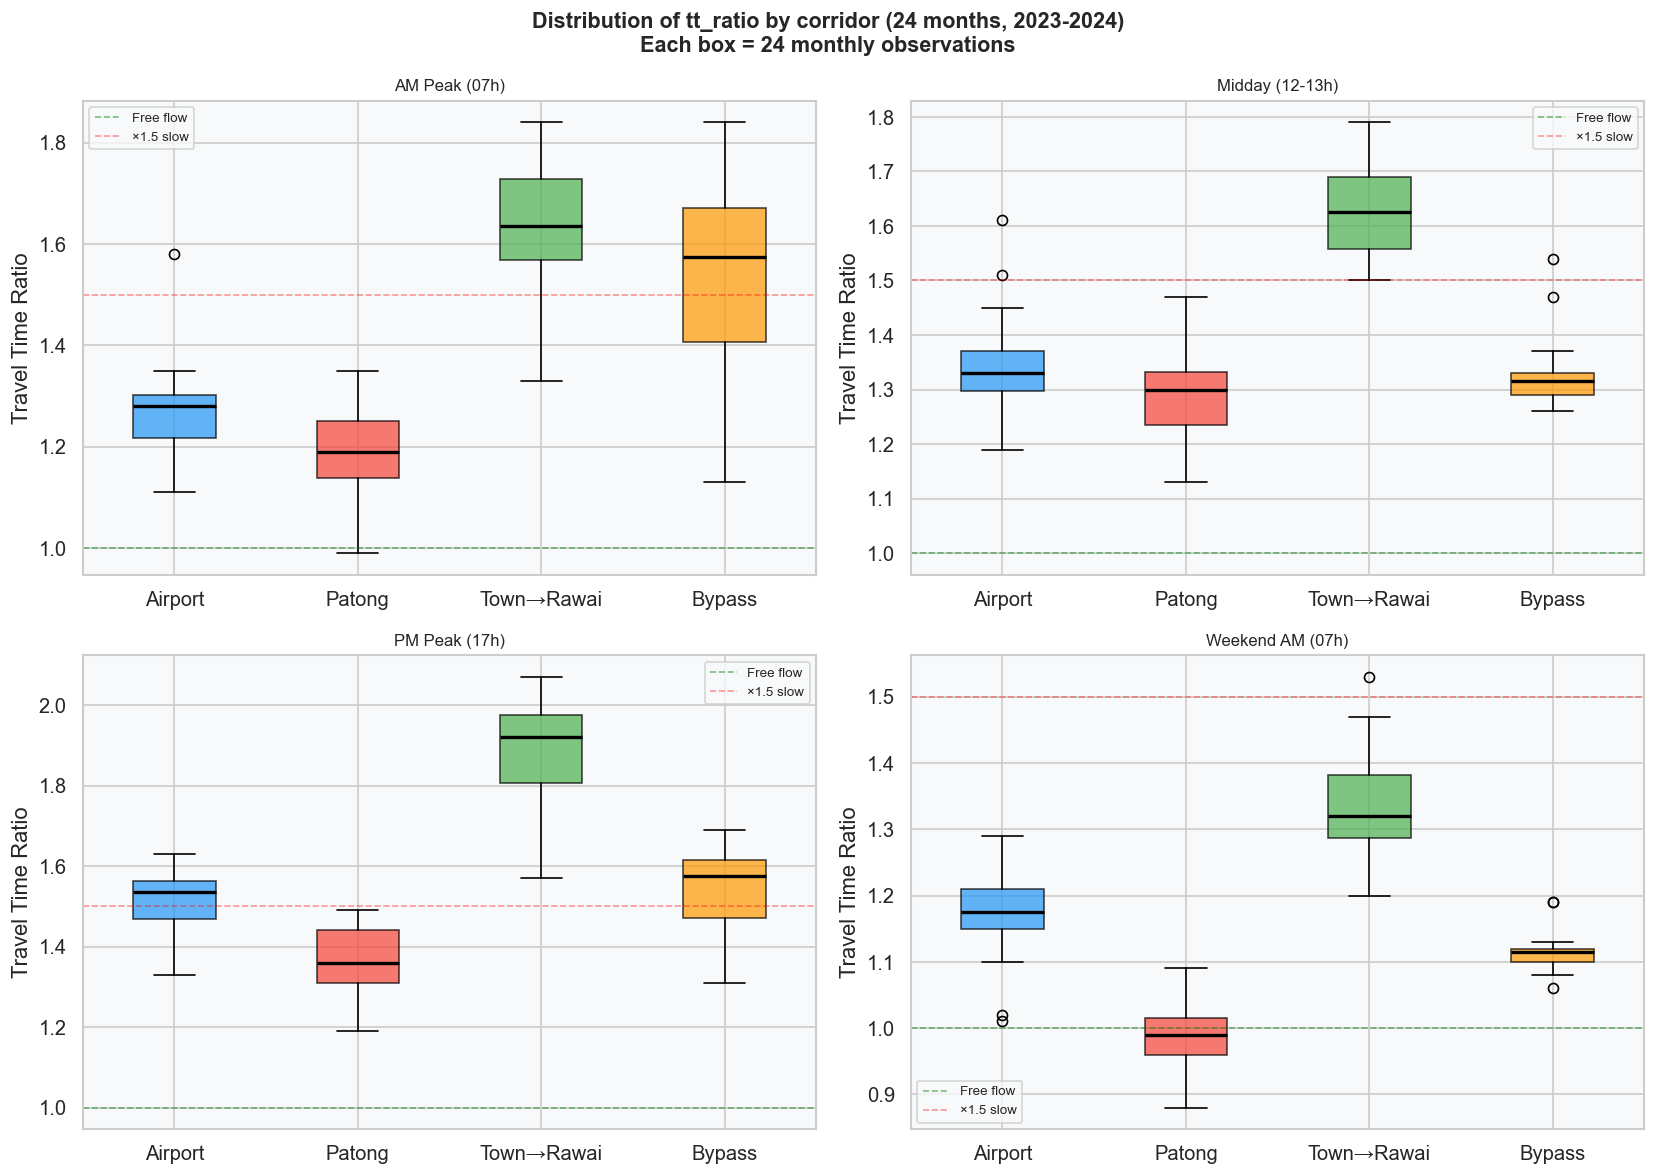

In [106]:
# Boxplot tt_ratio per corridor - distribution over 24 months, 4 representative timesets
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution of tt_ratio by corridor (24 months, 2023-2024)\n'
             'Each box = 24 monthly observations', fontsize=13, fontweight='bold')

for ax, ts in zip(axes.flat, REP_TIMESETS):
    col = f'tt_ratio_{ts}'
    corr_list = list(df['corridor'].unique())
    data_list = [df[df['corridor']==c][col].values for c in corr_list]
    labels    = [CORRIDOR_SHORT[c] for c in corr_list]
    colors    = [CORRIDOR_COLORS[c] for c in corr_list]
    bp = ax.boxplot(data_list, labels=labels, patch_artist=True,
                    medianprops={'color':'black','linewidth':2})
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color); patch.set_alpha(0.7)
    ax.axhline(1.0, color='green',  linestyle='--', linewidth=1, alpha=0.5, label='Free flow')
    ax.axhline(1.5, color='red',    linestyle='--', linewidth=1, alpha=0.4, label='×1.5 slow')
    ax.set_title(f'{REP_LABELS[ts]}', fontsize=10)
    ax.set_ylabel('Travel Time Ratio')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('../final_data/figures/fig_targets_by_corridor.png', bbox_inches='tight', facecolor='white')
plt.show()

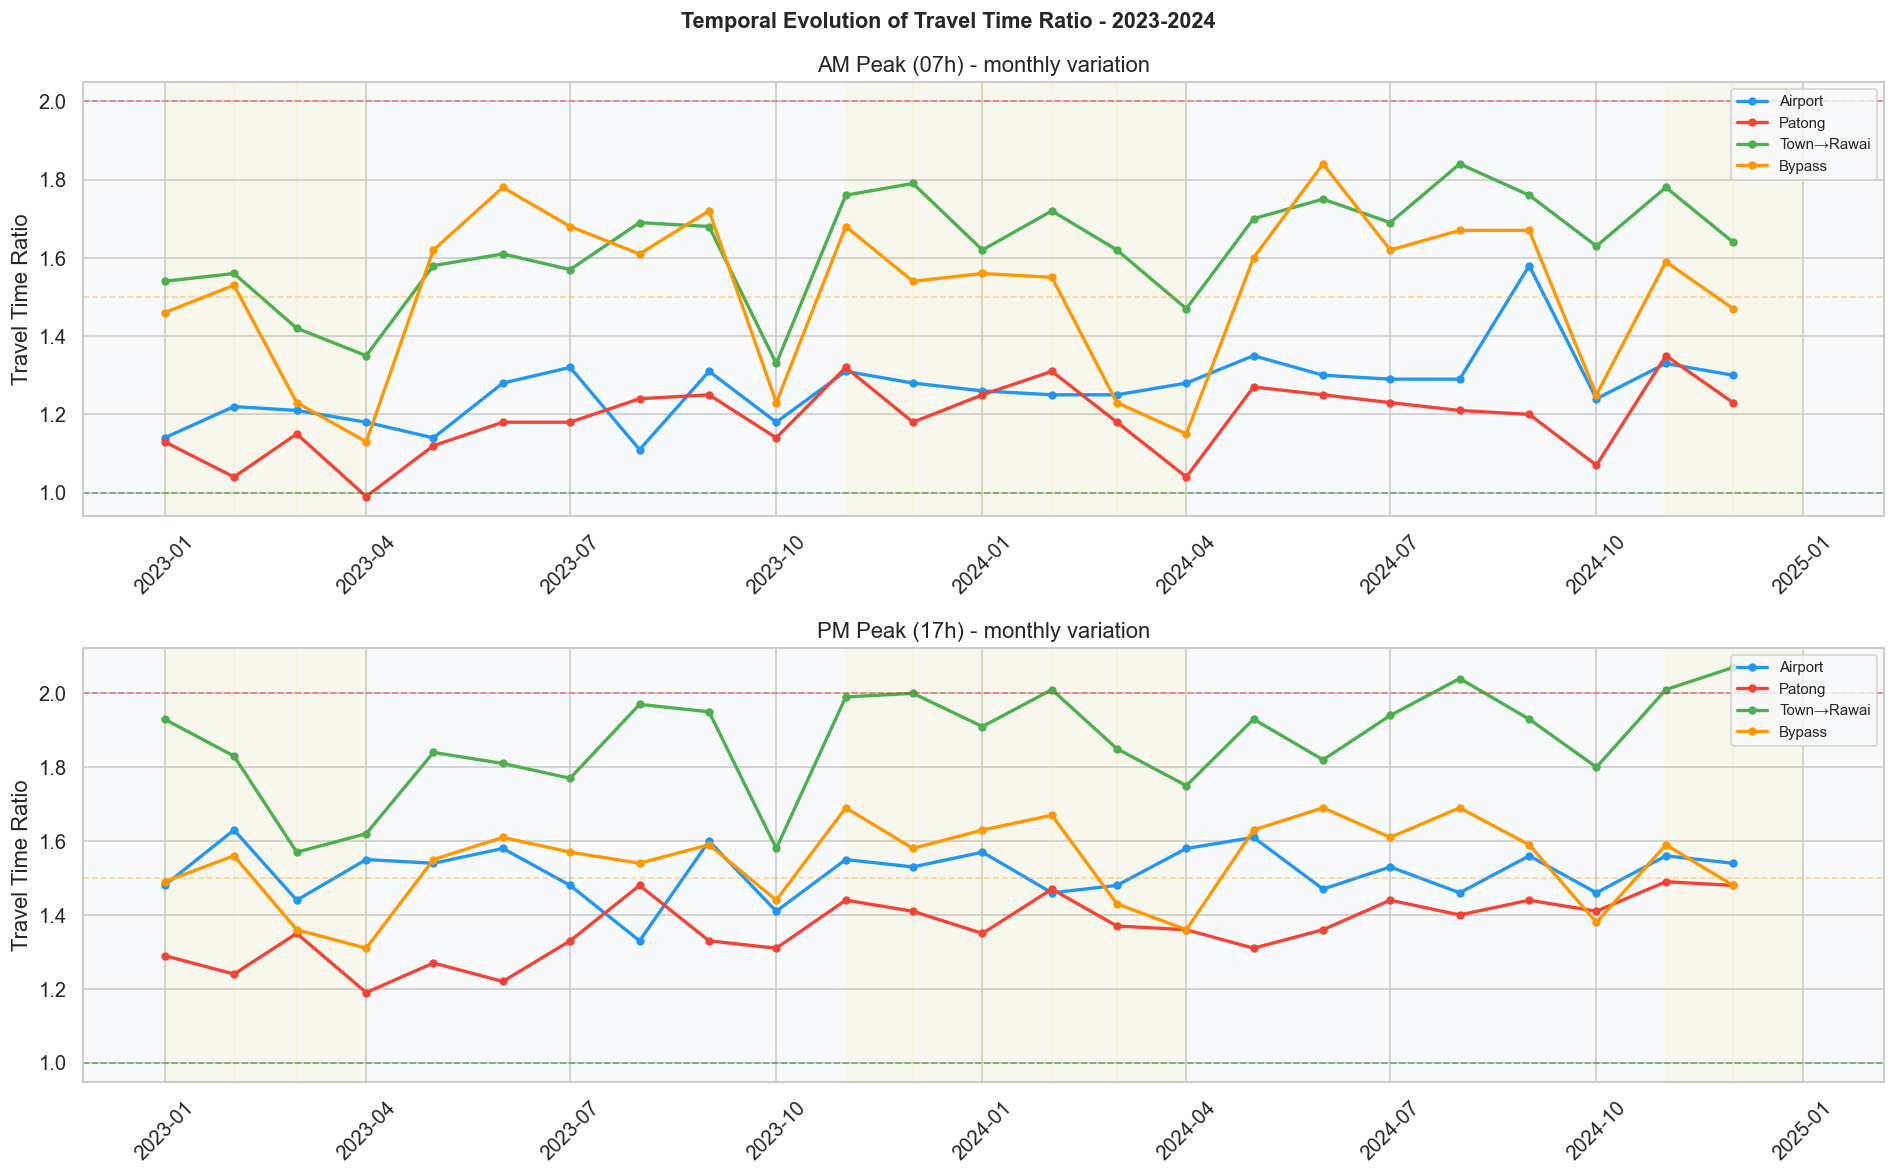

In [107]:
# Temporal evolution of tt_ratio - AM Peak and PM Peak, all corridors
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Temporal Evolution of Travel Time Ratio - 2023-2024', fontsize=13, fontweight='bold')

for ax, ts in zip(axes, ['Weekday_AM1','Weekday_PM1']):
    col = f'tt_ratio_{ts}'
    for corr in df['corridor'].unique():
        sub = df[df['corridor']==corr].sort_values('date')
        ax.plot(sub['date'], sub[col], 'o-', linewidth=2, markersize=4,
                label=CORRIDOR_SHORT[corr], color=CORRIDOR_COLORS[corr])
    ax.axhline(1.0, color='green',  linestyle='--', linewidth=1, alpha=0.5)
    ax.axhline(1.5, color='orange', linestyle='--', linewidth=1, alpha=0.4)
    ax.axhline(2.0, color='red',    linestyle='--', linewidth=1, alpha=0.4)
    ax.set_title(f'{REP_LABELS[ts]} - monthly variation')
    ax.set_ylabel('Travel Time Ratio')
    ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
    ax.tick_params(axis='x', rotation=45)
    ax.legend(loc='upper right', fontsize=9)
    # Shade high season
    for _, row in df[df['corr_id']==0].iterrows():
        if row['is_high_season']:
            ax.axvspan(row['date'], row['date'] + pd.DateOffset(months=1), alpha=0.05, color='gold')

plt.tight_layout()
plt.savefig('../final_data/figures/fig_temporal_ttr.png', bbox_inches='tight', facecolor='white')
plt.show()

## 5. Profil journalier complet (24 timesets)

> **Section clé** : courbe de congestion heure par heure pour chaque corridor.  
> Visualise les pics AM/PM, la nuit calme, et les différences semaine/weekend.


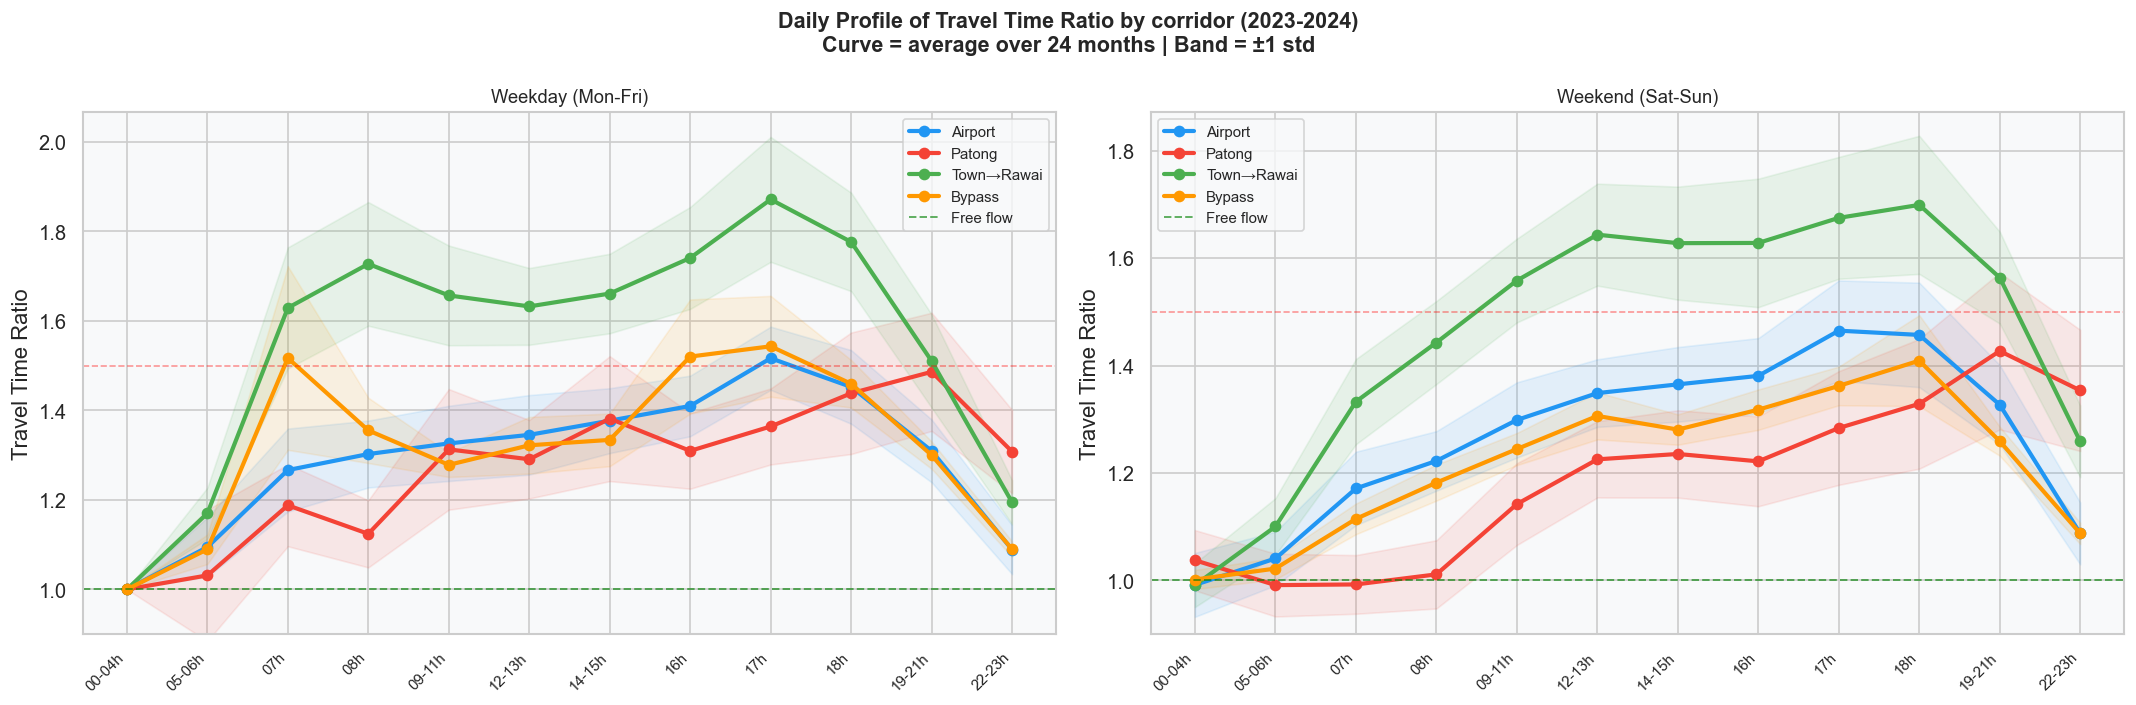

In [108]:
# Full daily profile - average tt_ratio 2023-2024 per corridor
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Daily Profile of Travel Time Ratio by corridor (2023-2024)\n'
             'Curve = average over 24 months | Band = ±1 std', fontsize=13, fontweight='bold')

for ax, (order, labels, title) in zip(axes, [
    (WEEKDAY_ORDER, WEEKDAY_LABELS, 'Weekday (Mon-Fri)'),
    (WEEKEND_ORDER, WEEKDAY_LABELS, 'Weekend (Sat-Sun)'),
]):
    for corr in df['corridor'].unique():
        sub   = df[df['corridor']==corr]
        means = [sub[f'tt_ratio_{ts}'].mean() for ts in order]
        stds  = [sub[f'tt_ratio_{ts}'].std()  for ts in order]
        x = range(len(order))
        ax.plot(x, means, 'o-', linewidth=2.5, markersize=6,
                label=CORRIDOR_SHORT[corr], color=CORRIDOR_COLORS[corr])
        ax.fill_between(x, [m-s for m,s in zip(means,stds)],
                           [m+s for m,s in zip(means,stds)],
                        alpha=0.1, color=CORRIDOR_COLORS[corr])
    ax.axhline(1.0, color='green', linestyle='--', linewidth=1.2, alpha=0.6, label='Free flow')
    ax.axhline(1.5, color='red',   linestyle='--', linewidth=1,   alpha=0.4)
    ax.set_xticks(range(len(order)))
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
    ax.set_title(title, fontsize=11)
    ax.set_ylabel('Travel Time Ratio')
    ax.legend(fontsize=9)
    ax.set_ylim(bottom=0.9)

plt.tight_layout()
plt.savefig('../final_data/figures/fig_daily_profile.png', bbox_inches='tight', facecolor='white')
plt.show()

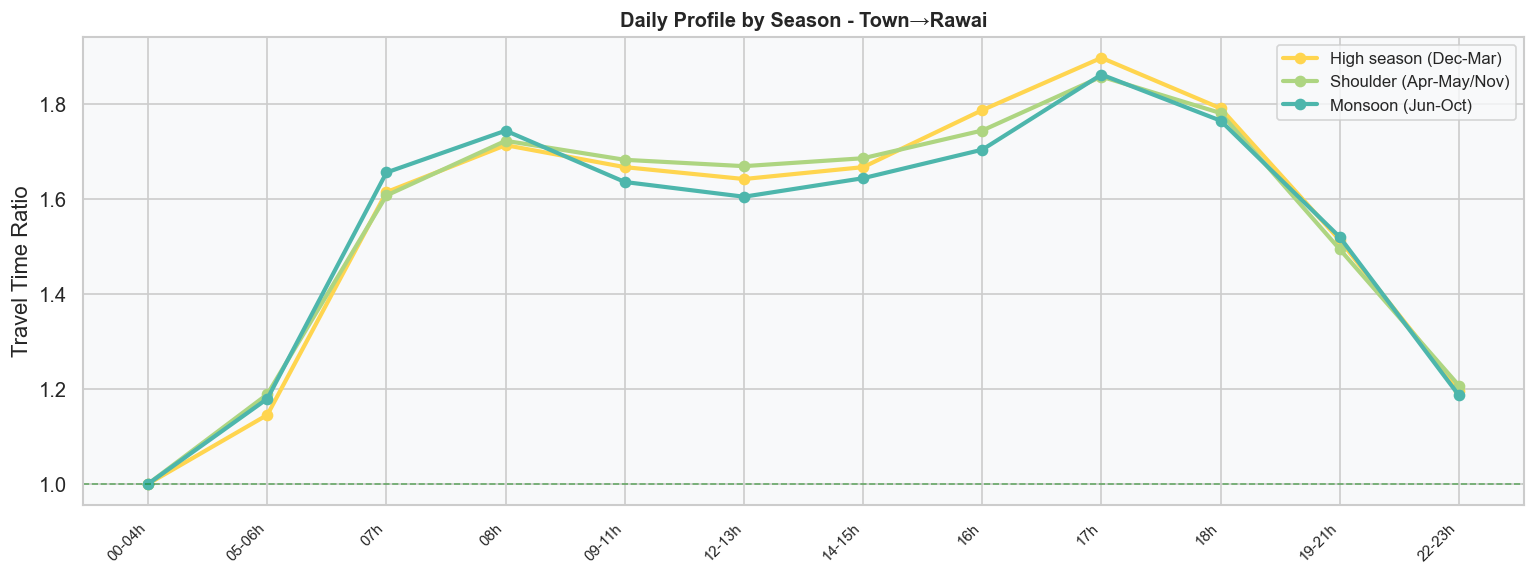

In [109]:
# Profil journalier - tt_ratio par SAISON pour Phuket Town→Rawai (corridor le plus congestionné)
target_corr = 'Phuket Town → Rawai (Route 4022)'
sub = df[df['corridor']==target_corr]

fig, ax = plt.subplots(figsize=(13, 5))
season_colors = {'high_peak':'#FFD54F','shoulder':'#AED581','monsoon':'#4DB6AC'}

for season in SEASON_ORDER:
    sub_s = sub[sub['season']==season]
    if len(sub_s) == 0: continue
    means = [sub_s[f'tt_ratio_{ts}'].mean() for ts in WEEKDAY_ORDER]
    ax.plot(range(len(WEEKDAY_ORDER)), means, 'o-', linewidth=2.5, markersize=6,
            label=SEASON_LABELS[season], color=season_colors[season])

ax.axhline(1.0, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax.set_xticks(range(len(WEEKDAY_ORDER)))
ax.set_xticklabels(WEEKDAY_LABELS, rotation=45, ha='right', fontsize=9)
ax.set_title(f'Daily Profile by Season - {CORRIDOR_SHORT[target_corr]}', fontsize=12, fontweight='bold')
ax.set_ylabel('Travel Time Ratio')
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('../final_data/figures/fig_daily_profile_season.png', bbox_inches='tight')
plt.show()


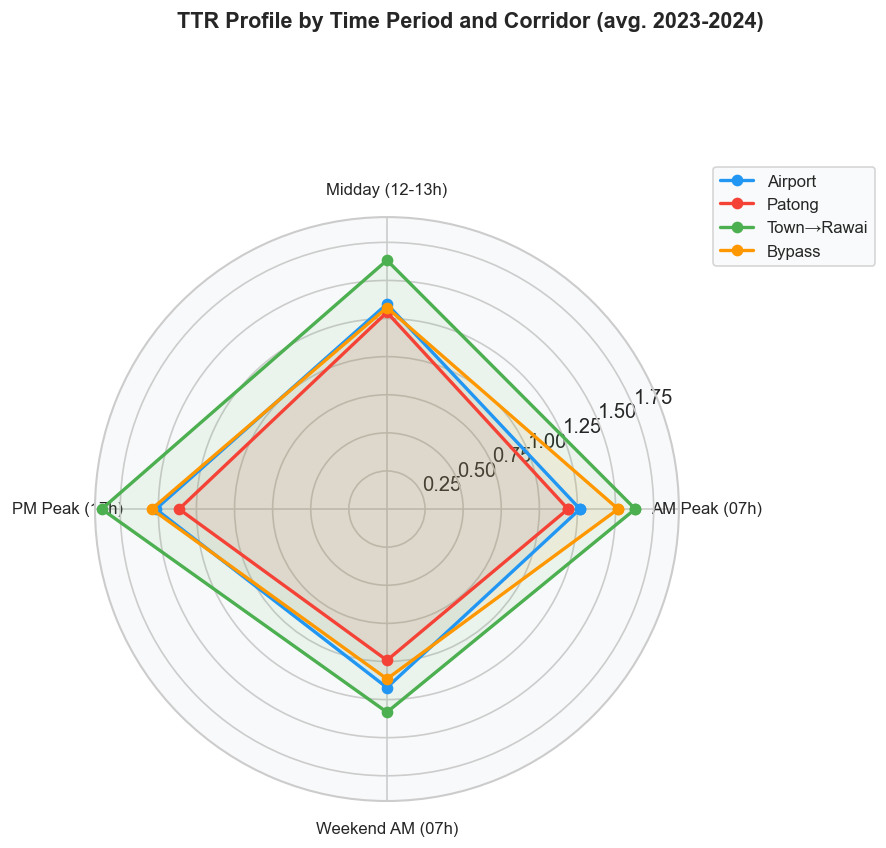

In [110]:
# Radar chart - 4 timesets représentatifs par corridor
tt_cols = [f'tt_ratio_{ts}' for ts in REP_TIMESETS]
labels  = [REP_LABELS[ts]   for ts in REP_TIMESETS]
n = len(labels)
angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist() + [0]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
fig.suptitle('TTR Profile by Time Period and Corridor (avg. 2023-2024)', fontsize=13, fontweight='bold')

for corr in df['corridor'].unique():
    sub    = df[df['corridor']==corr]
    values = sub[tt_cols].mean().tolist() + [sub[tt_cols[0]].mean()]
    ax.plot(angles, values, 'o-', linewidth=2, label=CORRIDOR_SHORT[corr], color=CORRIDOR_COLORS[corr])
    ax.fill(angles, values, alpha=0.08, color=CORRIDOR_COLORS[corr])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels, fontsize=10)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)
plt.tight_layout()
plt.savefig('../final_data/figures/fig_radar_ttr.png', bbox_inches='tight')
plt.show()


## 6. Évolution temporelle des features exogènes (2023-2024)


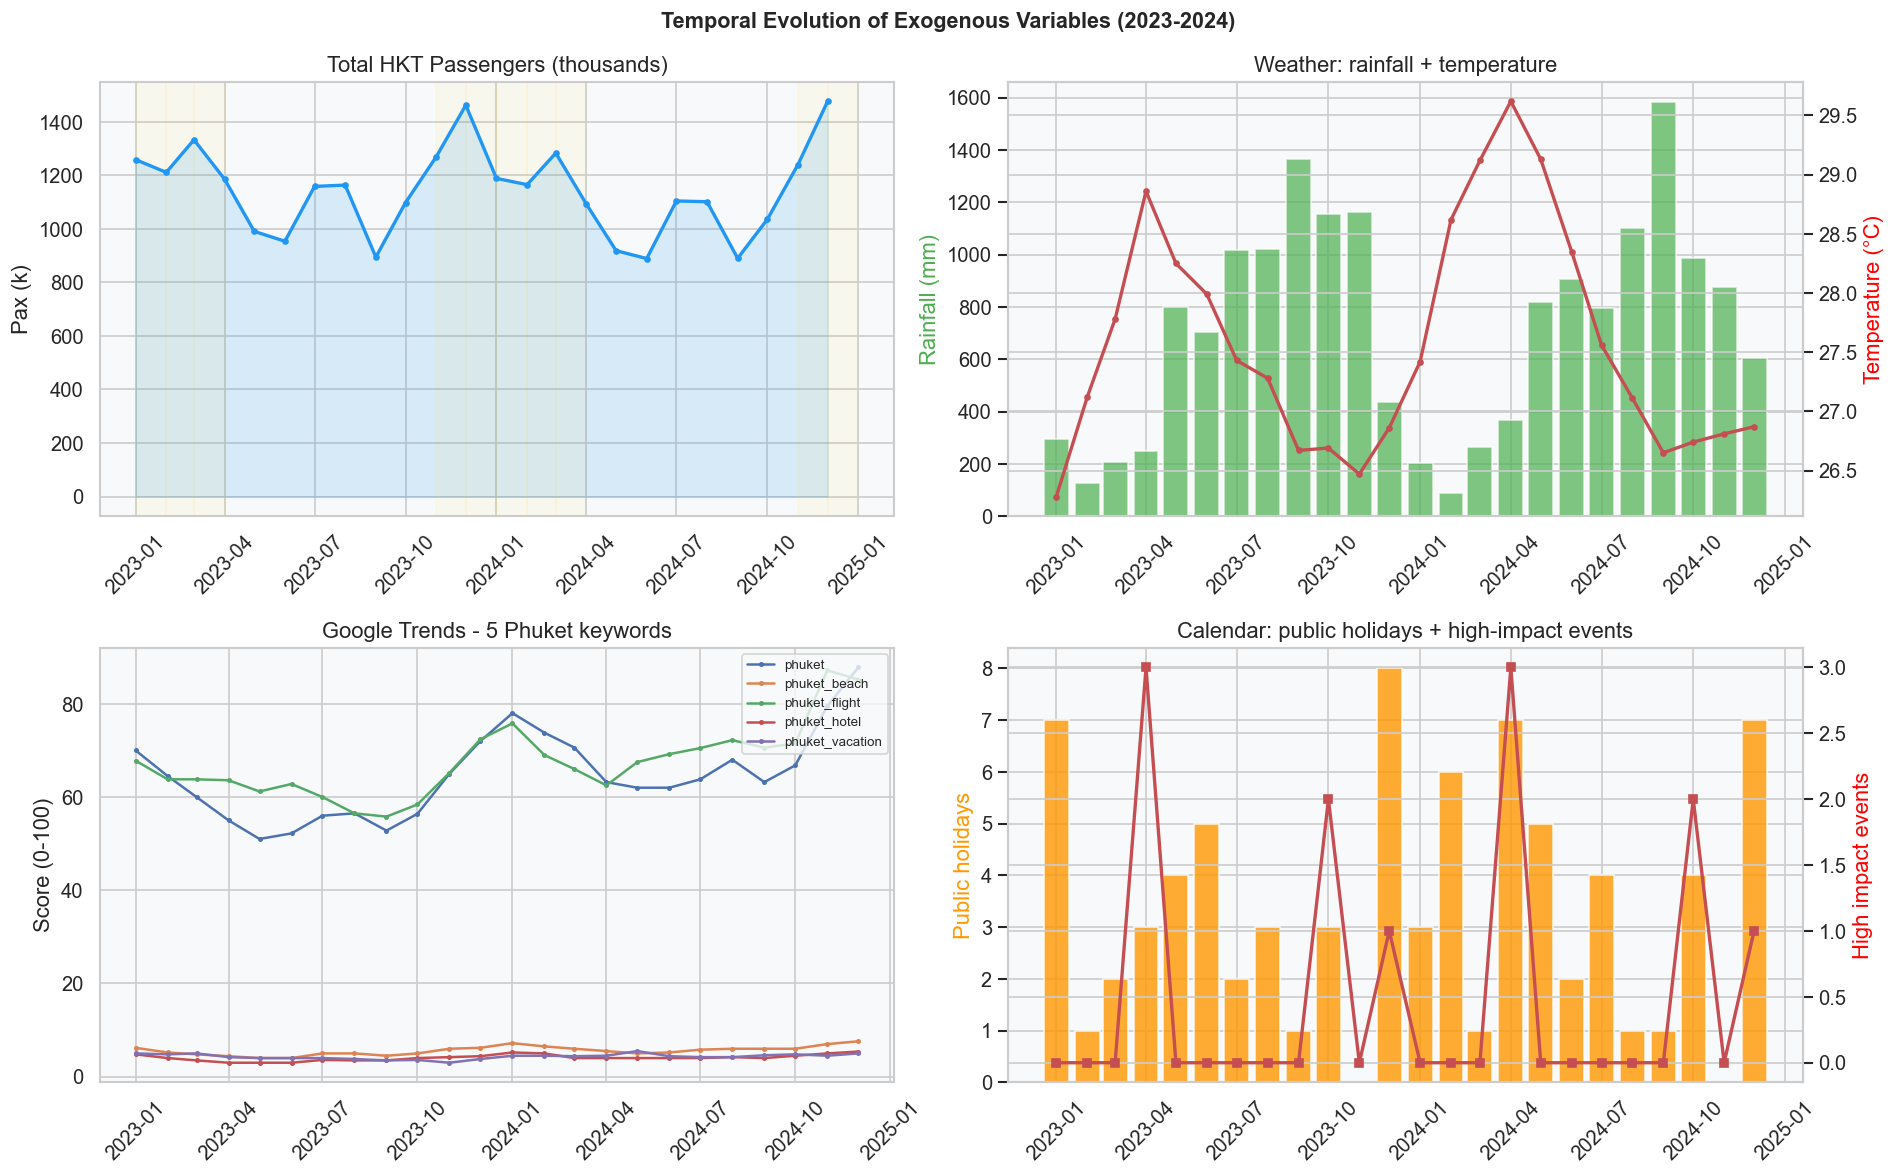

In [111]:
df_a = df[df['corr_id']==0].sort_values('date').copy()  # Airport Road ref

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Temporal Evolution of Exogenous Variables (2023-2024)', fontsize=13, fontweight='bold')

ax = axes[0,0]
ax.plot(df_a['date'], df_a['flt_total_pax']/1000, color='#2196F3', linewidth=2, marker='o', markersize=3)
ax.fill_between(df_a['date'], df_a['flt_total_pax']/1000, alpha=0.15, color='#2196F3')
ax.set_title('Total HKT Passengers (thousands)')
ax.set_ylabel('Pax (k)')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)
for _, row in df_a.iterrows():
    if row['is_high_season']:
        ax.axvspan(row['date'], row['date'] + pd.DateOffset(months=1), alpha=0.05, color='gold')

ax = axes[0,1]
ax.bar(df_a['date'], df_a['wx_rain_mm_sum'], width=25, color='#4CAF50', alpha=0.7)
ax2 = ax.twinx()
ax2.plot(df_a['date'], df_a['wx_temp_c_mean'], 'r-o', linewidth=2, markersize=3)
ax.set_title('Weather: rainfall + temperature')
ax.set_ylabel('Rainfall (mm)', color='#4CAF50')
ax2.set_ylabel('Temperature (°C)', color='red')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)

ax = axes[1,0]
soc_cols = [c for c in COL_GROUPS['Social'] if c in df.columns]
for col in soc_cols:
    ax.plot(df_a['date'], df_a[col], linewidth=1.5, marker='o', markersize=2, label=col.replace('soc_',''))
ax.set_title('Google Trends - 5 Phuket keywords')
ax.set_ylabel('Score (0-100)')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)
ax.legend(fontsize=8, loc='upper right')

ax = axes[1,1]
ax.bar(df_a['date'], df_a['cal_n_holidays'], width=25, color='#FF9800', alpha=0.8)
ax2 = ax.twinx()
ax2.plot(df_a['date'], df_a['cal_high_impact'], 'r-s', linewidth=2, markersize=5)
ax.set_title('Calendar: public holidays + high-impact events')
ax.set_ylabel('Public holidays', color='#FF9800')
ax2.set_ylabel('High impact events', color='red')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../final_data/figures/fig_temporal_exogenous.png', bbox_inches='tight', facecolor='white')
plt.show()

## 7. Saisonnalité mensuelle


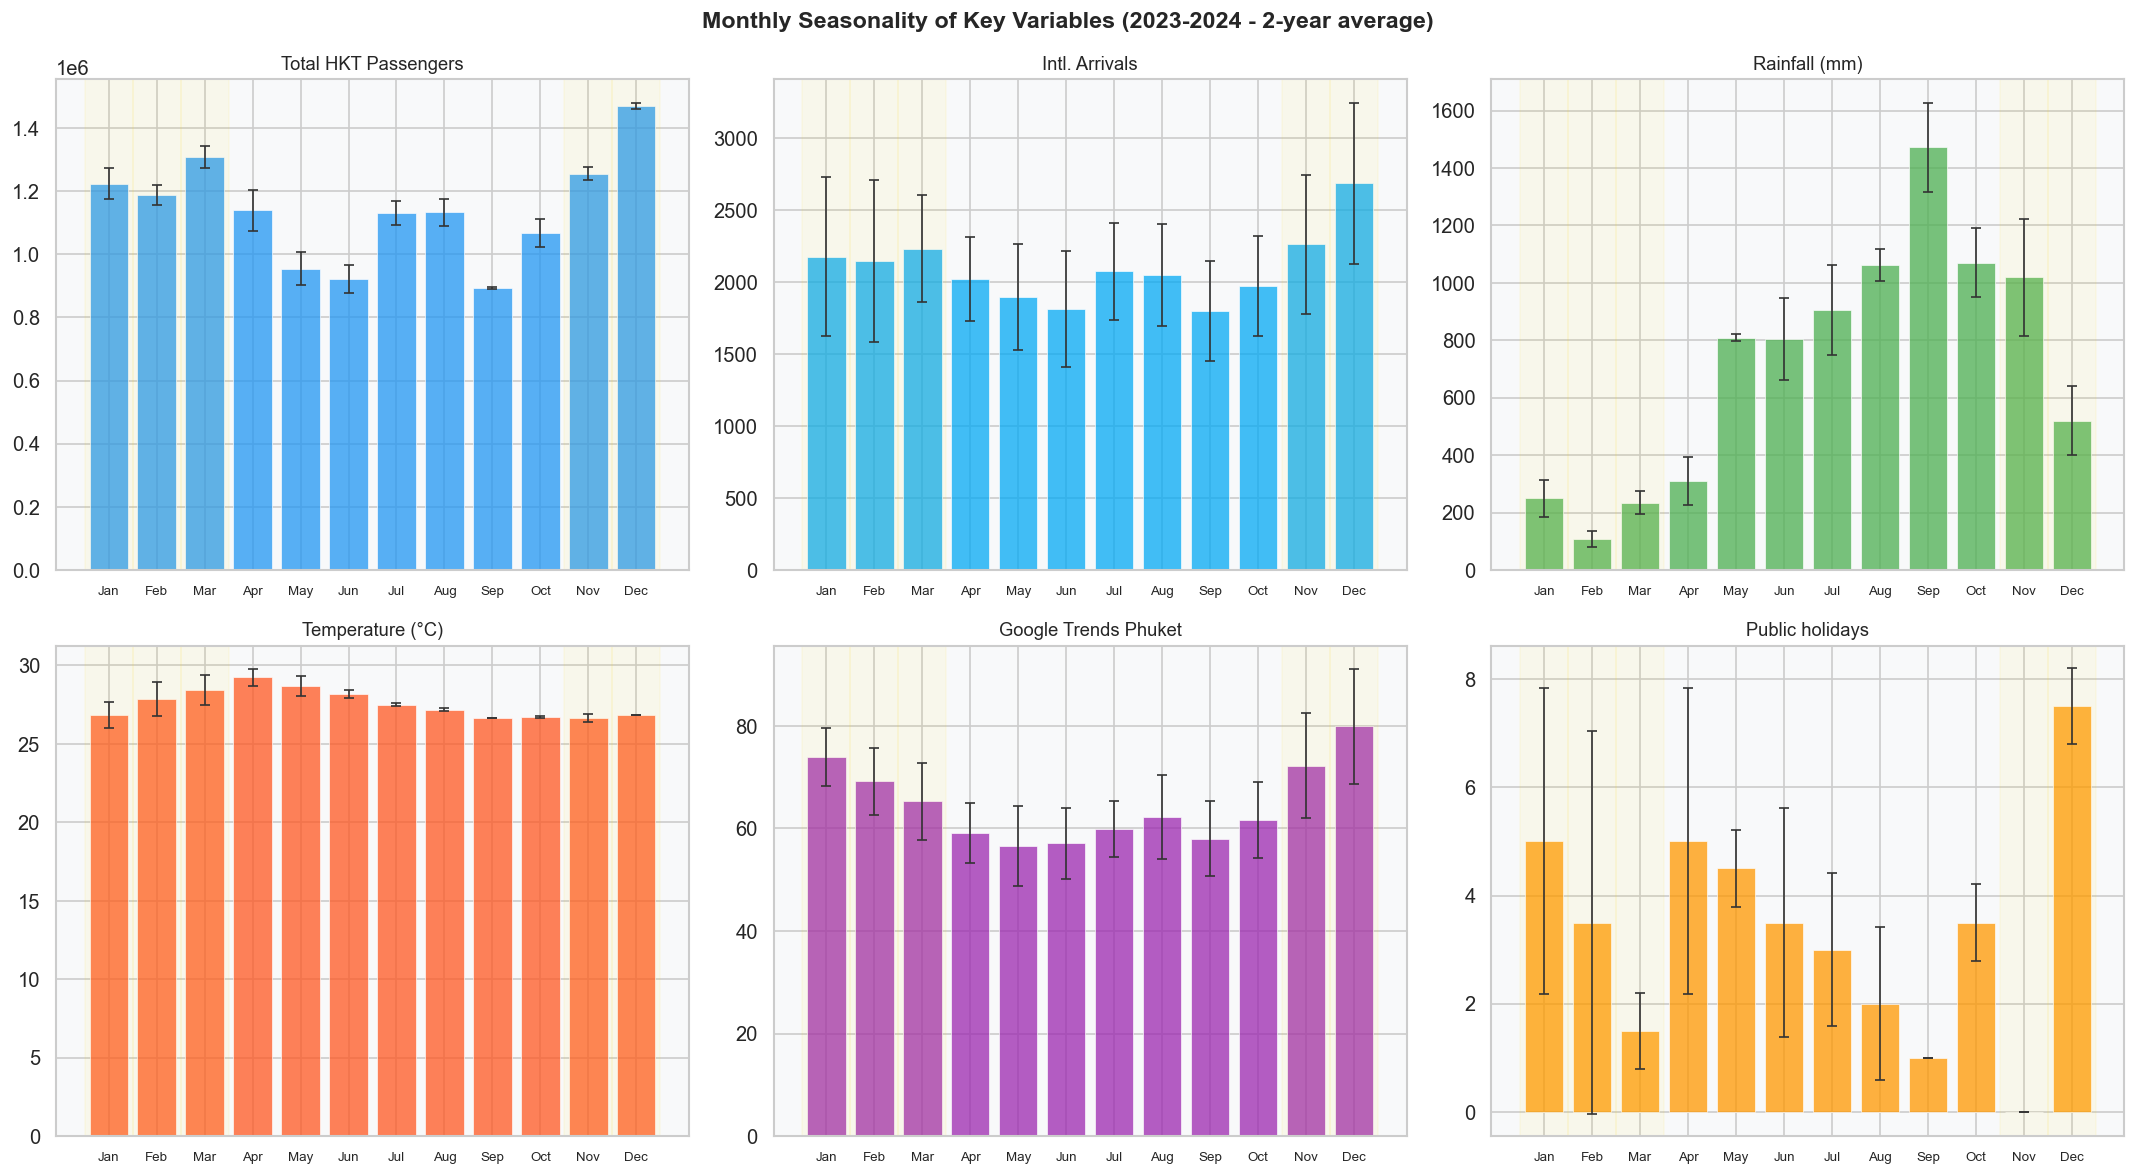

Gold zone = high season (Nov-Mar)


In [112]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Monthly Seasonality of Key Variables (2023-2024 - 2-year average)',
             fontsize=14, fontweight='bold')

seasonal_vars = [
    ('flt_total_pax',    'Total HKT Passengers',  '#2196F3'),
    ('flt_intl_arrivals','Intl. Arrivals',         '#03A9F4'),
    ('wx_rain_mm_sum',   'Rainfall (mm)',           '#4CAF50'),
    ('wx_temp_c_mean',   'Temperature (°C)',        '#FF5722'),
    ('soc_phuket',       'Google Trends Phuket',   '#9C27B0'),
    ('cal_n_holidays',   'Public holidays',         '#FF9800'),
]

for ax, (col, label, color) in zip(axes.flat, seasonal_vars):
    df_month = df_a.groupby('month')[col].agg(['mean','std']).reset_index()
    ax.bar(df_month['month'], df_month['mean'], color=color, alpha=0.75,
           edgecolor='white', linewidth=0.5)
    ax.errorbar(df_month['month'], df_month['mean'], yerr=df_month['std'],
                fmt='none', color='#333', capsize=3, linewidth=1)
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(MONTH_LABELS, fontsize=8)
    ax.set_title(label, fontsize=11)
    for m in [1,2,3,11,12]:
        ax.axvspan(m-0.5, m+0.5, alpha=0.06, color='gold')

plt.tight_layout()
plt.savefig('../final_data/figures/fig_seasonality.png', bbox_inches='tight', facecolor='white')
plt.show()
print('Gold zone = high season (Nov-Mar)')

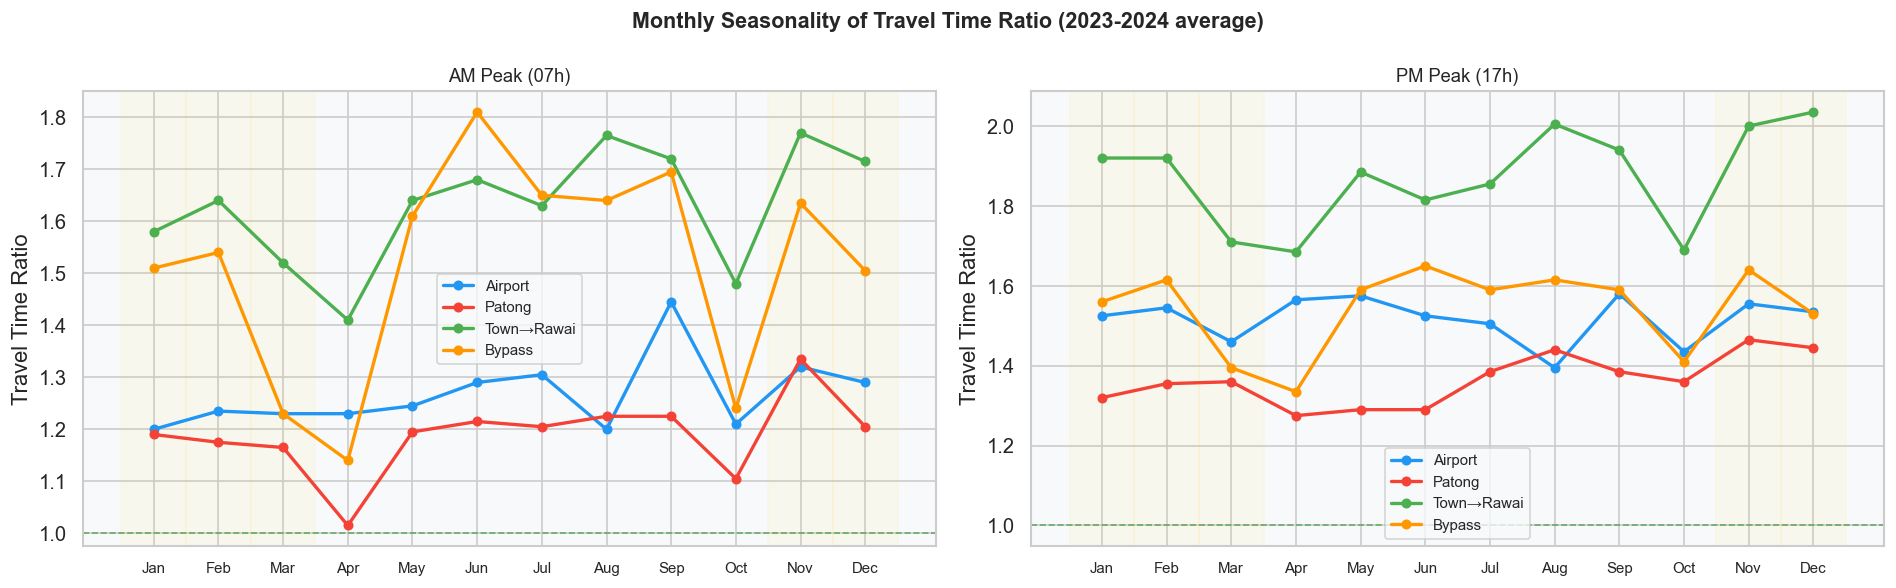

In [113]:
# Saisonnalité du trafic - tt_ratio AM et PM par mois, tous corridors
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Monthly Seasonality of Travel Time Ratio (2023-2024 average)',
             fontsize=13, fontweight='bold')

for ax, ts in zip(axes, ['Weekday_AM1','Weekday_PM1']):
    col = f'tt_ratio_{ts}'
    for corr in df['corridor'].unique():
        sub = df[df['corridor']==corr].groupby('month')[col].mean()
        ax.plot(sub.index, sub.values, 'o-', linewidth=2, markersize=5,
                label=CORRIDOR_SHORT[corr], color=CORRIDOR_COLORS[corr])
    ax.set_xticks(range(1,13))
    ax.set_xticklabels(MONTH_LABELS, fontsize=9)
    ax.set_title(REP_LABELS[ts], fontsize=11)
    ax.set_ylabel('Travel Time Ratio')
    ax.axhline(1.0, color='green', linestyle='--', linewidth=1, alpha=0.5)
    ax.legend(fontsize=9)
    for m in [1,2,3,11,12]:
        ax.axvspan(m-0.5, m+0.5, alpha=0.05, color='gold')

plt.tight_layout()
plt.savefig('../final_data/figures/fig_season_ttr.png', bbox_inches='tight')
plt.show()


## 8. Analyse de corrélation


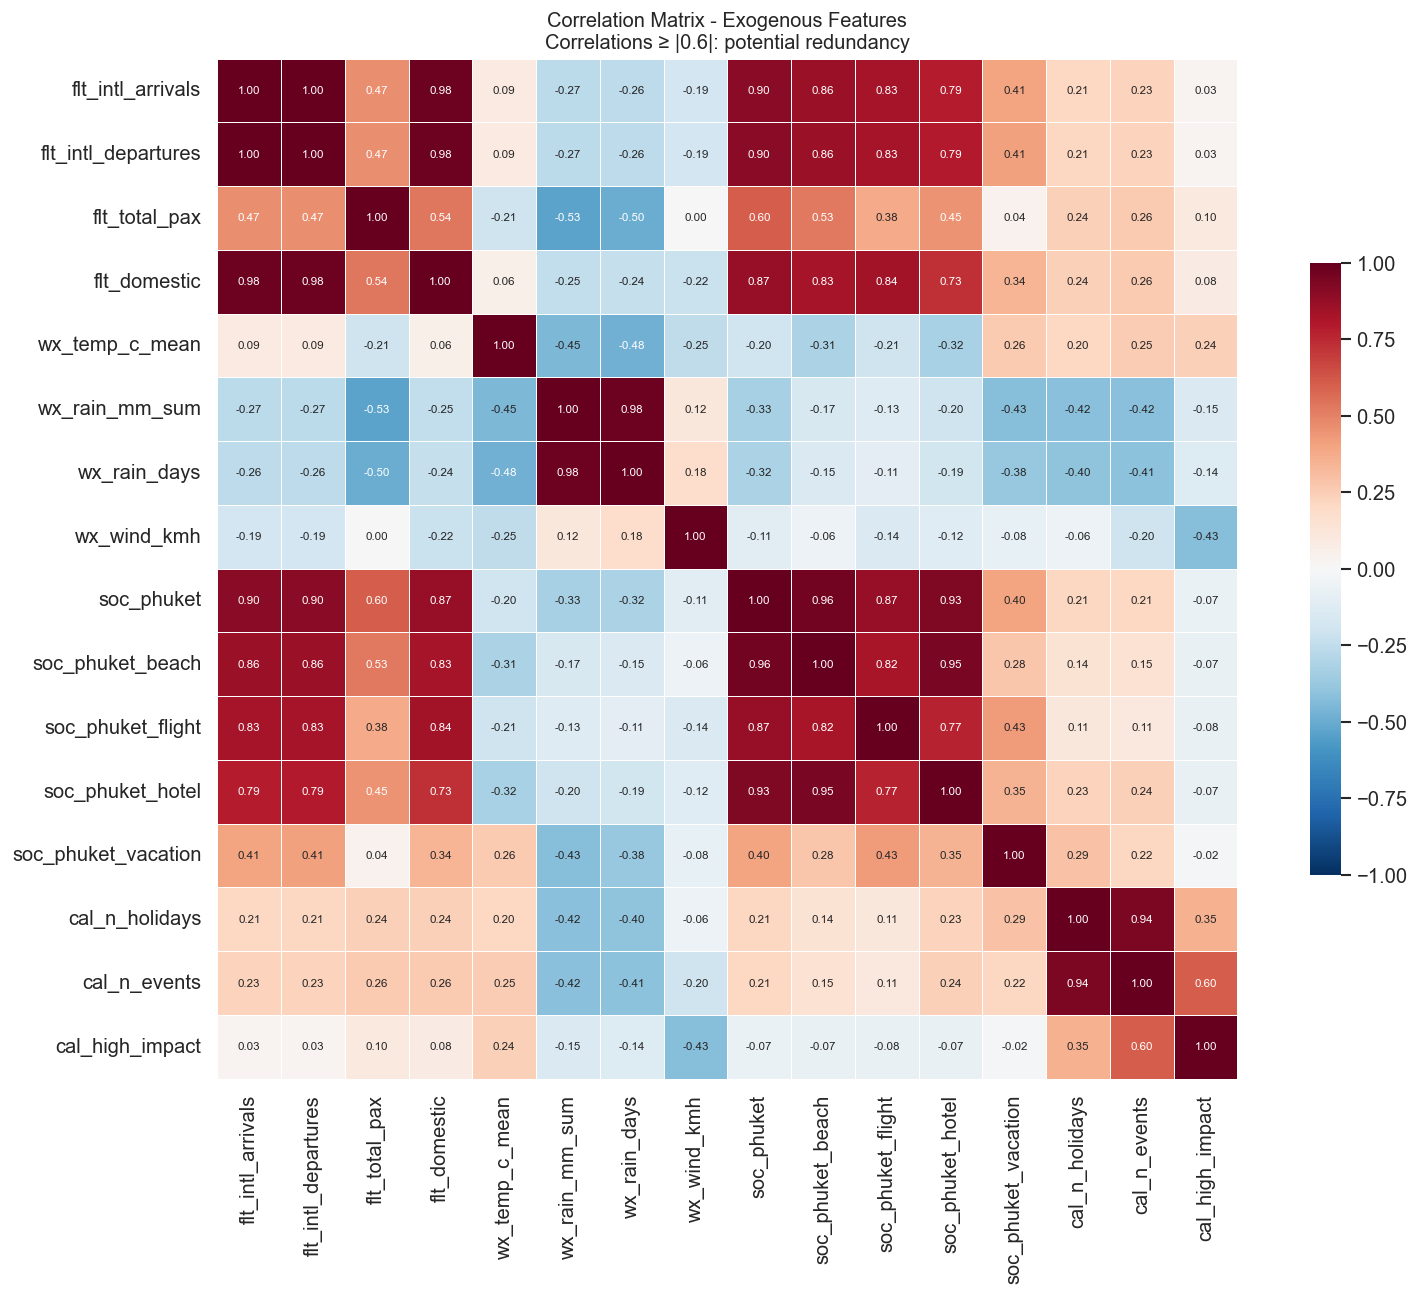


Highly correlated pairs (|r| > 0.7):
  flt_intl_arrivals              × flt_intl_departures            → r=1.00
  flt_intl_arrivals              × flt_domestic                   → r=0.98
  flt_intl_arrivals              × soc_phuket                     → r=0.90
  flt_intl_arrivals              × soc_phuket_beach               → r=0.86
  flt_intl_arrivals              × soc_phuket_flight              → r=0.83
  flt_intl_arrivals              × soc_phuket_hotel               → r=0.79
  flt_intl_departures            × flt_domestic                   → r=0.98
  flt_intl_departures            × soc_phuket                     → r=0.90
  flt_intl_departures            × soc_phuket_beach               → r=0.86
  flt_intl_departures            × soc_phuket_flight              → r=0.83
  flt_intl_departures            × soc_phuket_hotel               → r=0.79
  flt_domestic                   × soc_phuket                     → r=0.87
  flt_domestic                   × soc_phuket_beach           

In [114]:
exo_cols = ([c for c in COL_GROUPS['Flights']  if c in df.columns] +
            [c for c in COL_GROUPS['Weather']  if c in df.columns] +
            [c for c in COL_GROUPS['Social']   if c in df.columns] +
            [c for c in COL_GROUPS['Calendar'] if c in df.columns])

# Correlation between exogenous features (Airport Road = 24 temporal observations)
corr_exo = df_a[exo_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(14, 11))
sns.heatmap(corr_exo, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, square=True, linewidths=0.5,
            annot_kws={'size': 7}, cbar_kws={'shrink': 0.6})
ax.set_title('Correlation Matrix - Exogenous Features\n'
             'Correlations ≥ |0.6|: potential redundancy', fontsize=12)
plt.tight_layout()
plt.savefig('../final_data/figures/fig_corr_exogenous.png', bbox_inches='tight', facecolor='white')
plt.show()

print('\nHighly correlated pairs (|r| > 0.7):')
for i in range(len(corr_exo.columns)):
    for j in range(i+1, len(corr_exo.columns)):
        r = corr_exo.iloc[i, j]
        if abs(r) > 0.7:
            print(f'  {corr_exo.columns[i]:30s} × {corr_exo.columns[j]:30s} → r={r:.2f}')

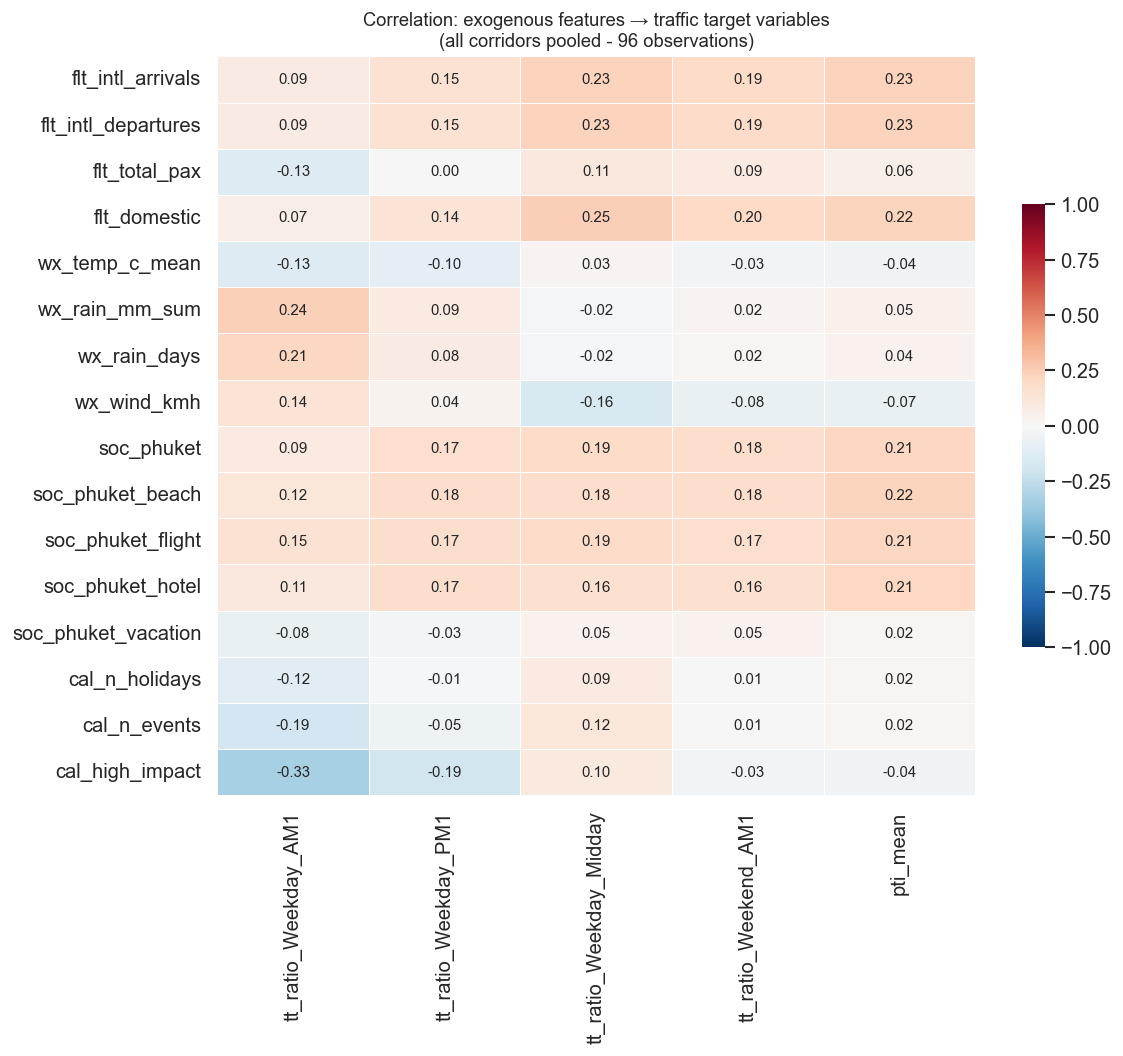


Top correlations (|r| > 0.3) with tt_ratio_Weekday_AM1:
cal_high_impact    0.33166


In [115]:
# Correlation exogenous features → traffic targets (all corridors pooled - 96 obs)
target_cols = ['tt_ratio_Weekday_AM1','tt_ratio_Weekday_PM1',
               'tt_ratio_Weekday_Midday','tt_ratio_Weekend_AM1','pti_mean']
corr_full = df[exo_cols + target_cols + ['corr_id']].corr(numeric_only=True)
corr_vs_target = corr_full.loc[exo_cols, target_cols]

fig, ax = plt.subplots(figsize=(10, 9))
sns.heatmap(corr_vs_target, ax=ax, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, linewidths=0.5, annot_kws={'size': 9},
            cbar_kws={'shrink': 0.6})
ax.set_title('Correlation: exogenous features → traffic target variables\n'
             '(all corridors pooled - 96 observations)', fontsize=11)
plt.tight_layout()
plt.savefig('../final_data/figures/fig_corr_exo_vs_targets.png', bbox_inches='tight', facecolor='white')
plt.show()

print('\nTop correlations (|r| > 0.3) with tt_ratio_Weekday_AM1:')
top = corr_vs_target['tt_ratio_Weekday_AM1'].abs().sort_values(ascending=False)
print(top[top > 0.3].to_string())

## 9. Relations bivariées : features exogènes × trafic

> Features trafic dynamiques → on peut analyser les co-évolutions temporelles réelles.


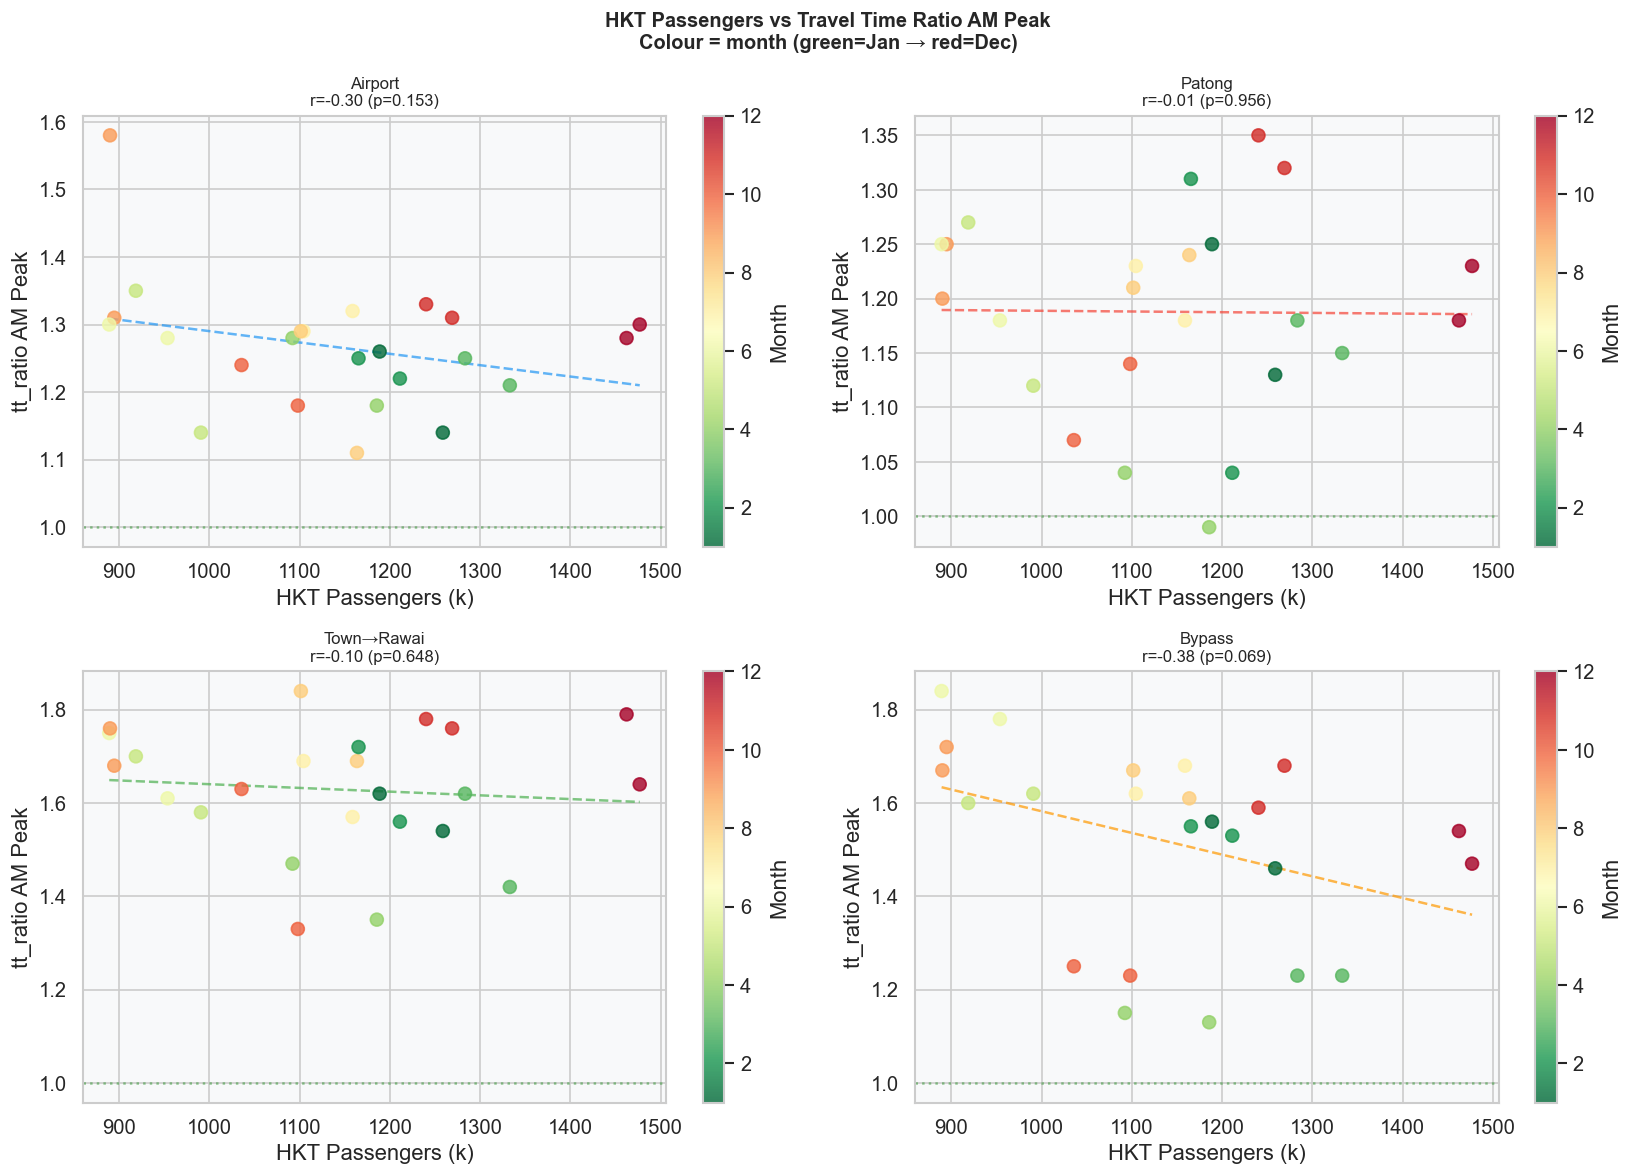

In [116]:
# Scatter HKT Passengers vs tt_ratio AM Peak - per corridor, coloured by month
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('HKT Passengers vs Travel Time Ratio AM Peak\nColour = month (green=Jan → red=Dec)',
             fontsize=12, fontweight='bold')

for ax, corr in zip(axes.flat, df['corridor'].unique()):
    sub = df[df['corridor']==corr].sort_values('date')
    sc  = ax.scatter(sub['flt_total_pax']/1000, sub['tt_ratio_Weekday_AM1'],
                     c=sub['month'], cmap='RdYlGn_r', s=60, zorder=3, alpha=0.8)
    z = np.polyfit(sub['flt_total_pax']/1000, sub['tt_ratio_Weekday_AM1'], 1)
    xr = np.linspace(sub['flt_total_pax'].min()/1000, sub['flt_total_pax'].max()/1000, 50)
    ax.plot(xr, np.poly1d(z)(xr), '--', color=CORRIDOR_COLORS[corr], linewidth=1.5, alpha=0.7)
    r, pv = stats.pearsonr(sub['flt_total_pax'], sub['tt_ratio_Weekday_AM1'])
    ax.set_title(f'{CORRIDOR_SHORT[corr]}\nr={r:.2f} (p={pv:.3f})', fontsize=10)
    ax.set_xlabel('HKT Passengers (k)')
    ax.set_ylabel('tt_ratio AM Peak')
    ax.axhline(1.0, color='green', linestyle=':', alpha=0.4)
    plt.colorbar(sc, ax=ax, label='Month')

plt.tight_layout()
plt.savefig('../final_data/figures/fig_flights_vs_ttr.png', bbox_inches='tight', facecolor='white')
plt.show()

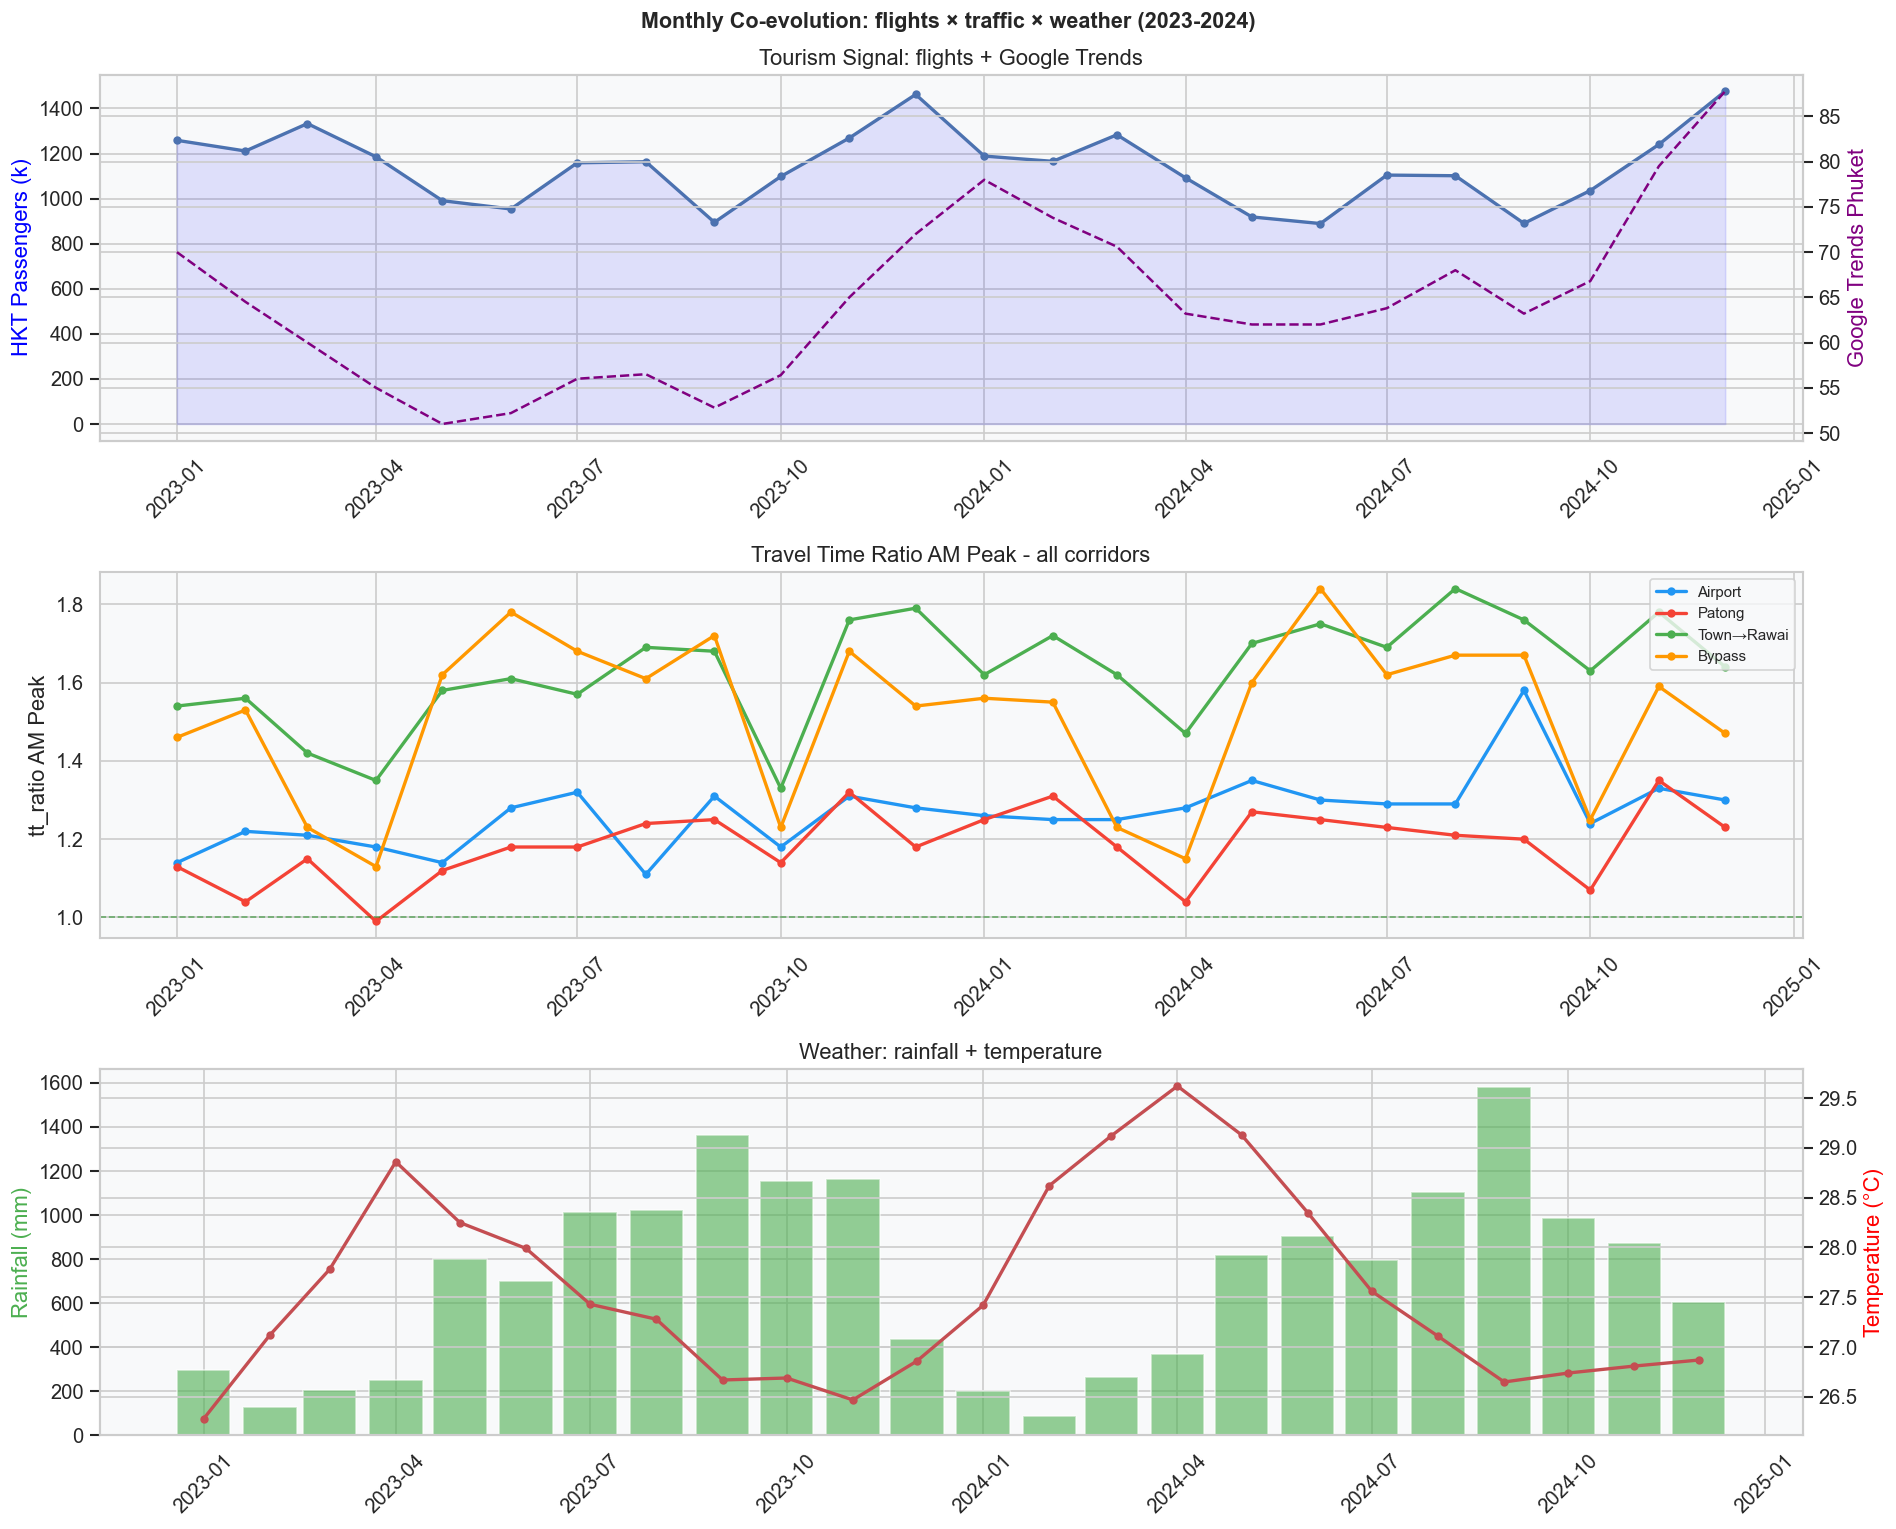

In [117]:
# Monthly co-evolution: flights × traffic AM Peak × weather
fig, axes = plt.subplots(3, 1, figsize=(16, 13))
fig.suptitle('Monthly Co-evolution: flights × traffic × weather (2023-2024)',
             fontsize=13, fontweight='bold')

ax = axes[0]
ax.plot(df_a['date'], df_a['flt_total_pax']/1000, 'b-o', linewidth=2, markersize=4)
ax.fill_between(df_a['date'], df_a['flt_total_pax']/1000, alpha=0.1, color='blue')
ax2 = ax.twinx()
ax2.plot(df_a['date'], df_a['soc_phuket'], 'purple', linewidth=1.5, linestyle='--')
ax.set_ylabel('HKT Passengers (k)', color='blue')
ax2.set_ylabel('Google Trends Phuket', color='purple')
ax.set_title('Tourism Signal: flights + Google Trends')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)

ax = axes[1]
for corr in df['corridor'].unique():
    sub = df[df['corridor']==corr].sort_values('date')
    ax.plot(sub['date'], sub['tt_ratio_Weekday_AM1'], 'o-', linewidth=2, markersize=4,
            label=CORRIDOR_SHORT[corr], color=CORRIDOR_COLORS[corr])
ax.axhline(1.0, color='green', linestyle='--', linewidth=1, alpha=0.5)
ax.set_ylabel('tt_ratio AM Peak')
ax.set_title('Travel Time Ratio AM Peak - all corridors')
ax.legend(fontsize=9, loc='upper right')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)

ax = axes[2]
ax.bar(df_a['date'], df_a['wx_rain_mm_sum'], width=25, color='#4CAF50', alpha=0.6)
ax2 = ax.twinx()
ax2.plot(df_a['date'], df_a['wx_temp_c_mean'], 'r-o', linewidth=2, markersize=4)
ax.set_ylabel('Rainfall (mm)', color='#4CAF50')
ax2.set_ylabel('Temperature (°C)', color='red')
ax.set_title('Weather: rainfall + temperature')
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../final_data/figures/fig_temporal_full.png', bbox_inches='tight', facecolor='white')
plt.show()

## 10. Comparaison inter-corridors


In [118]:
# Tableau de synthèse - moyennes 2023-2024
corridor_summary = df.groupby('corridor').agg(
    Km            = ('corr_length_km',        'first'),
    Tourist       = ('corr_tourist_access',    'first'),
    SPD_AM        = ('spd_Weekday_AM1',        'mean'),
    SPD_PM        = ('spd_Weekday_PM1',        'mean'),
    TTR_AM_mean   = ('tt_ratio_Weekday_AM1',   'mean'),
    TTR_AM_max    = ('tt_ratio_Weekday_AM1',   'max'),
    TTR_PM_mean   = ('tt_ratio_Weekday_PM1',   'mean'),
    PTI_mean      = ('pti_mean',               'mean'),
    PTI_max_ever  = ('pti_max',                'max'),
).round(3)
corridor_summary.index = [CORRIDOR_SHORT[c] for c in corridor_summary.index]
print('Synthèse des corridors (2023-2024) :')
display(corridor_summary)


Synthèse des corridors (2023-2024) :


,Km,Tourist,SPD_AM,SPD_PM,TTR_AM_mean,TTR_AM_max,TTR_PM_mean,PTI_mean,PTI_max_ever
Airport,20,1,42.552,35.516,1.267,1.58,1.517,2.545,3.93
Bypass,15,0,25.495,24.683,1.517,1.84,1.543,2.419,4.56
Patong,9,1,22.709,20.304,1.188,1.35,1.364,2.640,4.54
Town→Rawai,18,1,24.126,21.062,1.629,1.84,1.872,3.607,5.68


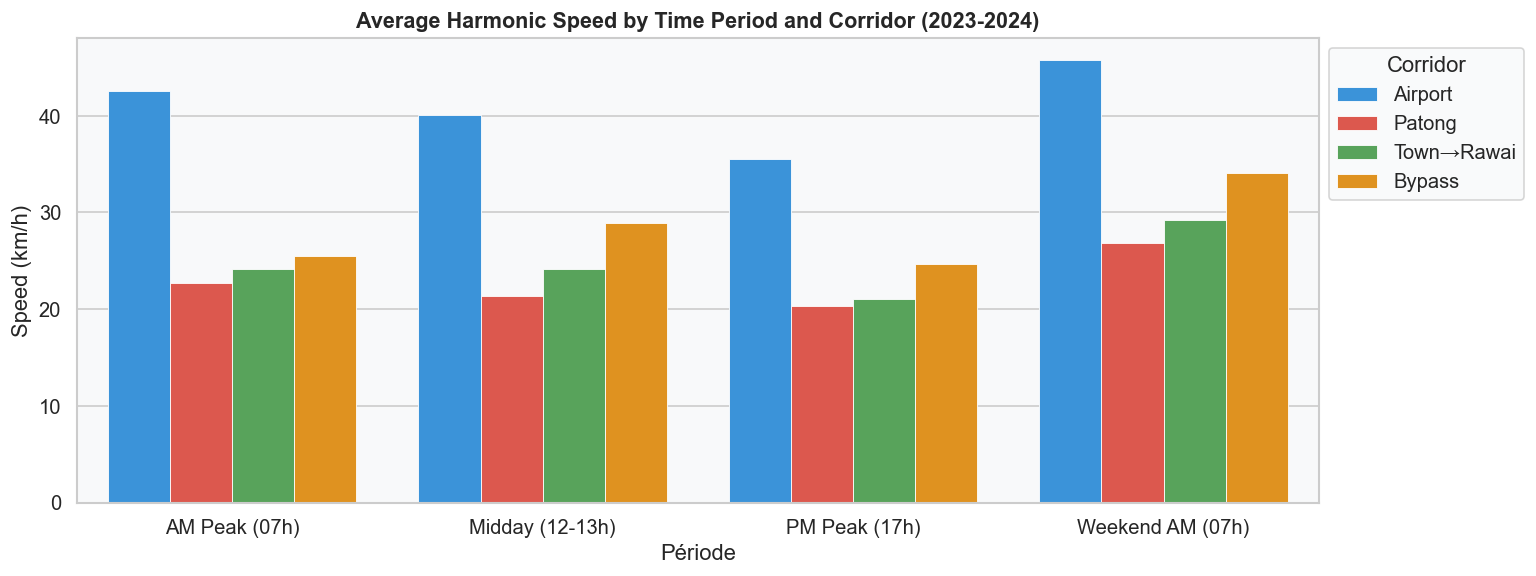

In [119]:
# Vitesse moyenne par période et corridor
spd_data = []
for ts in REP_TIMESETS:
    col = f'spd_{ts}'
    if col not in df.columns: continue
    for corr in df['corridor'].unique():
        spd_data.append({'Période': REP_LABELS[ts],
                         'Corridor': CORRIDOR_SHORT[corr],
                         'Speed (km/h)': df[df['corridor']==corr][col].mean()})
df_spd = pd.DataFrame(spd_data)

fig, ax = plt.subplots(figsize=(13, 5))
palette = {CORRIDOR_SHORT[k]: v for k, v in CORRIDOR_COLORS.items()}
sns.barplot(data=df_spd, x='Période', y='Speed (km/h)', hue='Corridor',
            palette=palette, ax=ax, edgecolor='white', linewidth=0.5)
ax.set_title('Average Harmonic Speed by Time Period and Corridor (2023-2024)',
             fontsize=13, fontweight='bold')
ax.legend(title='Corridor', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.savefig('../final_data/figures/fig_corridor_speed.png', bbox_inches='tight')
plt.show()


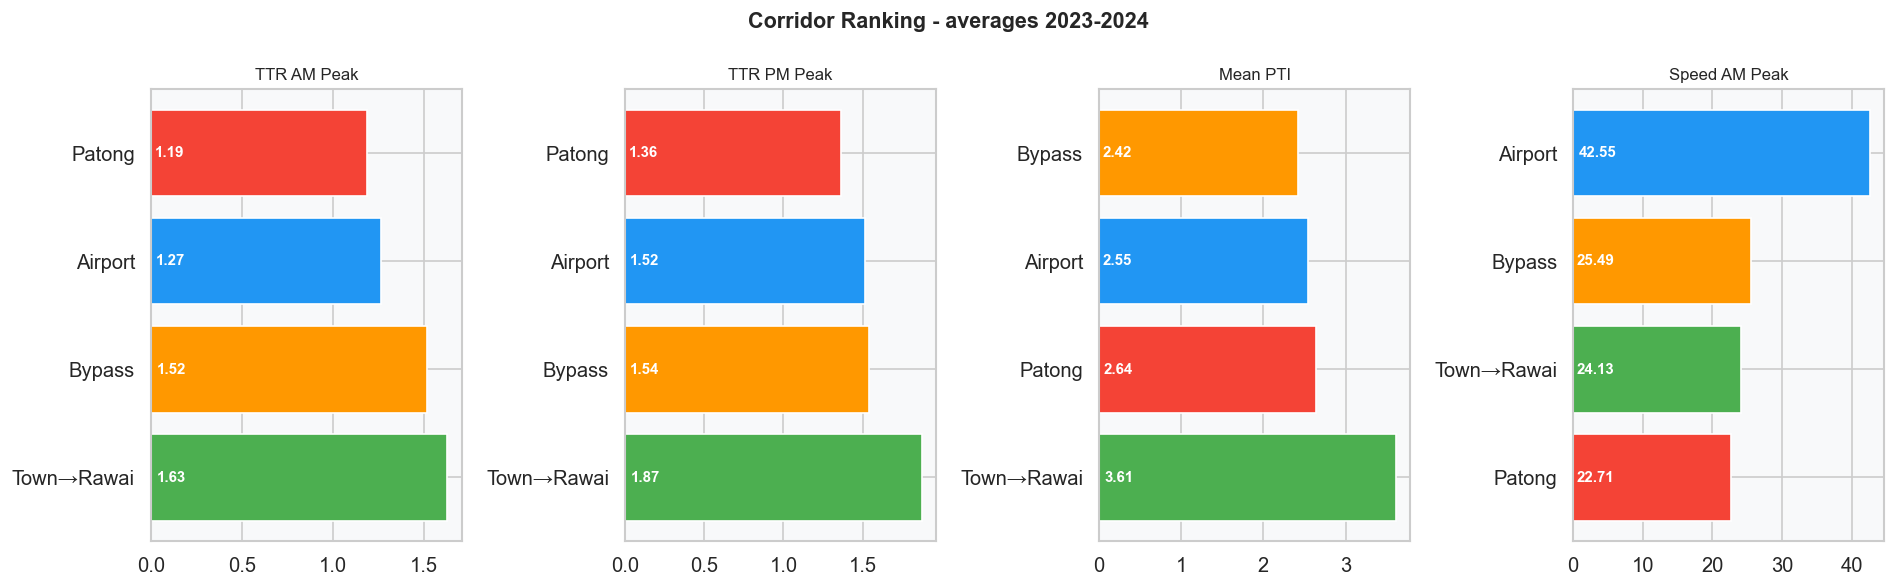

In [120]:
# Corridor ranking by metric
fig, axes = plt.subplots(1, 4, figsize=(16, 5))
fig.suptitle('Corridor Ranking - averages 2023-2024', fontsize=13, fontweight='bold')

metrics = [
    ('tt_ratio_Weekday_AM1', 'TTR AM Peak',  True),
    ('tt_ratio_Weekday_PM1', 'TTR PM Peak',  True),
    ('pti_mean',             'Mean PTI',     True),
    ('spd_Weekday_AM1',      'Speed AM Peak',False),
]

for ax, (col, label, higher_worse) in zip(axes, metrics):
    data = df.groupby('corridor')[col].mean().sort_values(ascending=not higher_worse).reset_index()
    colors = [CORRIDOR_COLORS[c] for c in data['corridor']]
    ax.barh(data['corridor'].map(CORRIDOR_SHORT), data[col], color=colors, edgecolor='white')
    ax.set_title(label, fontsize=10)
    for i, (_, row) in enumerate(data.iterrows()):
        ax.text(row[col]*0.02, i, f'{row[col]:.2f}', va='center',
                fontsize=9, color='white', fontweight='bold')

plt.tight_layout()
plt.savefig('../final_data/figures/fig_corridor_ranking.png', bbox_inches='tight', facecolor='white')
plt.show()

## 11. Distributions & normalité


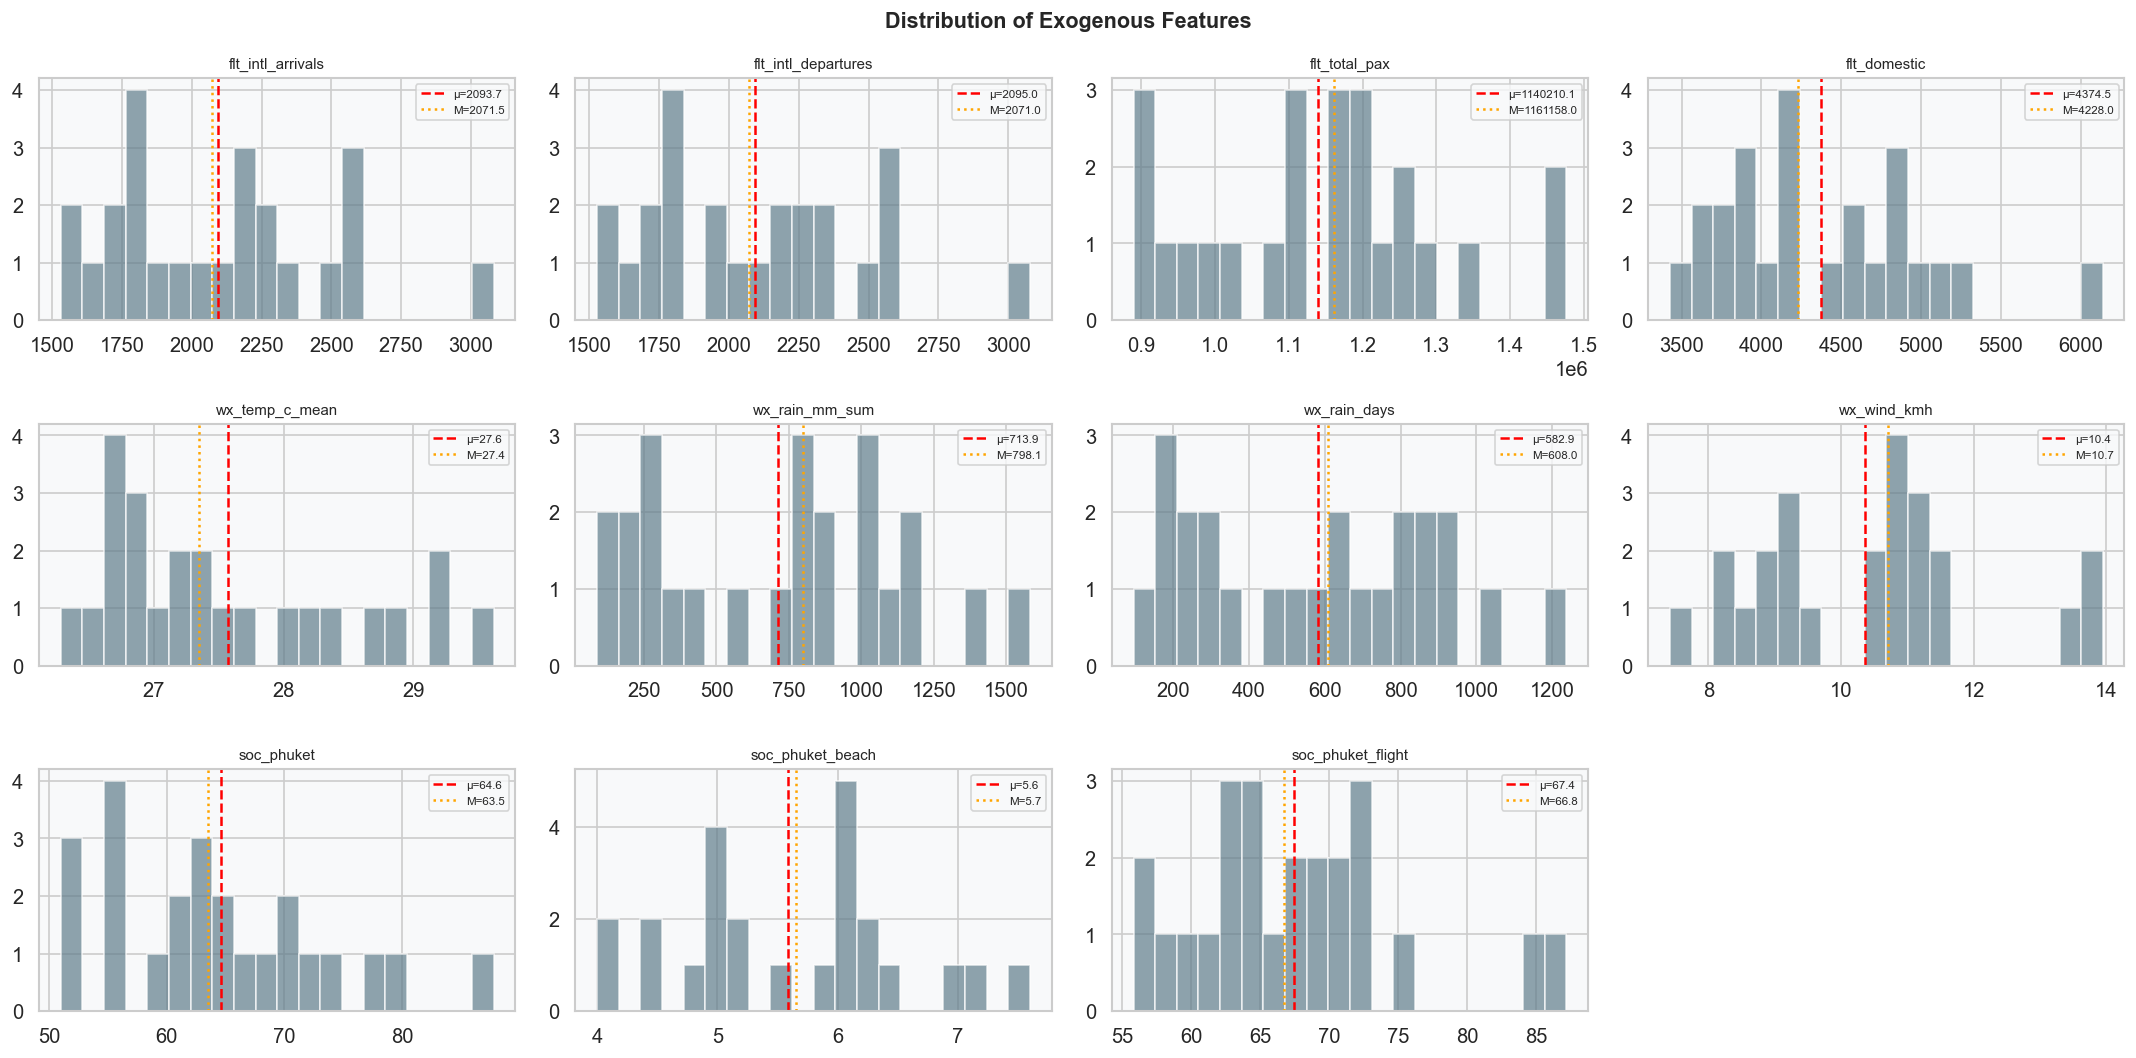

In [121]:
exo_plot = [c for c in
            COL_GROUPS['Flights'] + COL_GROUPS['Weather'] + COL_GROUPS['Social'][:3]
            if c in df.columns]
n_cols = 4
n_rows = (len(exo_plot) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows*3))
fig.suptitle('Distribution of Exogenous Features', fontsize=13, fontweight='bold')

for ax, col in zip(axes.flat, exo_plot):
    data = df_a[col].dropna()
    ax.hist(data, bins=20, color='#607D8B', alpha=0.7, edgecolor='white')
    ax.axvline(data.mean(),   color='red',    linestyle='--', linewidth=1.5, label=f'μ={data.mean():.1f}')
    ax.axvline(data.median(), color='orange', linestyle=':',  linewidth=1.5, label=f'M={data.median():.1f}')
    ax.set_title(col, fontsize=9)
    ax.legend(fontsize=7)

for ax in axes.flat[len(exo_plot):]:
    ax.set_visible(False)

plt.tight_layout()
plt.savefig('../final_data/figures/fig_exo_distributions.png', bbox_inches='tight')
plt.show()


In [122]:
# Tests de normalité Shapiro-Wilk
print('Tests de normalité Shapiro-Wilk (p < 0.05 → non-normal) :')
print(f"{'Variable':35s} {'Stat':8s} {'p-value':12s} {'Normal?'}")
print('-'*65)
for col in exo_cols[:12]:
    data = df_a[col].dropna()
    if len(data) >= 3:
        stat, p = stats.shapiro(data)
        normal = '✅ oui' if p > 0.05 else '❌ non'
        print(f'  {col:35s} {stat:.4f}   {p:.4f}       {normal}')


Tests de normalité Shapiro-Wilk (p < 0.05 → non-normal) :
Variable                            Stat     p-value      Normal?
-----------------------------------------------------------------
  flt_intl_arrivals                   0.9558   0.3591       ✅ oui
  flt_intl_departures                 0.9568   0.3767       ✅ oui
  flt_total_pax                       0.9570   0.3814       ✅ oui
  flt_domestic                        0.9469   0.2325       ✅ oui
  wx_temp_c_mean                      0.9196   0.0572       ✅ oui
  wx_rain_mm_sum                      0.9478   0.2427       ✅ oui
  wx_rain_days                        0.9491   0.2595       ✅ oui
  wx_wind_kmh                         0.9433   0.1936       ✅ oui
  soc_phuket                          0.9597   0.4329       ✅ oui
  soc_phuket_beach                    0.9660   0.5712       ✅ oui
  soc_phuket_flight                   0.9287   0.0912       ✅ oui
  soc_phuket_hotel                    0.9415   0.1766       ✅ oui


## 12. Analyse par saison


In [123]:
# Profil moyen par saison
season_exo = df_a.groupby('season')[exo_cols].mean().round(2)
print('Moyennes par saison - features exogènes :')
display(season_exo.T)

ttr_targets = [f'tt_ratio_{ts}' for ts in REP_TIMESETS]
season_ttr = df.groupby(['season','corridor'])[ttr_targets].mean().round(3)
print('\nTTR moyen par saison et corridor :')
display(season_ttr)


Moyennes par saison - features exogènes :


season,high_peak,monsoon,shoulder
flt_intl_arrivals,2309.88,1941.70,2058.83
flt_intl_departures,2312.25,1942.10,2060.33
flt_total_pax,1297361.00,1028976.70,1116064.50
flt_domestic,4696.75,4106.10,4392.00
wx_temp_c_mean,27.51,27.25,28.19
wx_rain_mm_sum,278.21,1063.32,712.50
wx_rain_days,262.12,844.20,575.00
wx_wind_kmh,10.76,10.92,8.93
soc_phuket,72.09,59.77,62.62
soc_phuket_beach,6.21,5.25,5.32



TTR moyen par saison et corridor :


tt_ratio_Weekday_AM1  \
season    corridor                                                 
high_peak Airport Road (Route 402)                         1.239   
          Bypass Road (Route 4027)                         1.446   
          Patong Hill (Route 4029)                         1.184   
          Phuket Town → Rawai (Route 4022)                 1.614   
monsoon   Airport Road (Route 402)                         1.290   
          Bypass Road (Route 4027)                         1.607   
          Patong Hill (Route 4029)                         1.195   
          Phuket Town → Rawai (Route 4022)                 1.655   
shoulder  Airport Road (Route 402)                         1.265   
          Bypass Road (Route 4027)                         1.462   
          Patong Hill (Route 4029)                         1.182   
          Phuket Town → Rawai (Route 4022)                 1.607   

                                            tt_ratio_Weekday_Midday  \
season    corridor                                                    
high_peak Airport Road (Route 402)                            1.356   
          Bypass Road (Route 4027)                            1.300   
          Patong Hill (Route 4029)                            1.306   
          Phuket Town → Rawai (Route 4022)                    1.641   
monsoon   Airport Road (Route 402)                            1.339   
          Bypass Road (Route 4027)                            1.322   
          Patong Hill (Route 4029)                            1.276   
          Phuket Town → Rawai (Route 4022)                    1.604   
shoulder  Airport Road (Route 402)                            1.342   
          Bypass Road (Route 4027)                            1.352   
          Patong Hill (Route 4029)                            1.295   
          Phuket Town → Rawai (Route 4022)                    1.668   

                                            tt_ratio_Weekday_PM1  \
season    corridor                                                 
high_peak Airport Road (Route 402)                         1.516   
          Bypass Road (Route 4027)                         1.525   
          Patong Hill (Route 4029)                         1.370   
          Phuket Town → Rawai (Route 4022)                 1.896   
monsoon   Airport Road (Route 402)                         1.488   
          Bypass Road (Route 4027)                         1.571   
          Patong Hill (Route 4029)                         1.372   
          Phuket Town → Rawai (Route 4022)                 1.861   
shoulder  Airport Road (Route 402)                         1.565   
          Bypass Road (Route 4027)                         1.522   
          Patong Hill (Route 4029)                         1.343   
          Phuket Town → Rawai (Route 4022)                 1.857   

                                            tt_ratio_Weekend_AM1  
season    corridor                                                
high_peak Airport Road (Route 402)                         1.158  
          Bypass Road (Route 4027)                         1.135  
          Patong Hill (Route 4029)                         0.999  
          Phuket Town → Rawai (Route 4022)                 1.350  
monsoon   Airport Road (Route 402)                         1.170  
          Bypass Road (Route 4027)                         1.108  
          Patong Hill (Route 4029)                         0.983  
          Phuket Town → Rawai (Route 4022)                 1.325  
shoulder  Airport Road (Route 402)                         1.192  
          Bypass Road (Route 4027)                         1.098  
          Patong Hill (Route 4029)                         1.000  
          Phuket Town → Rawai (Route 4022)                 1.323

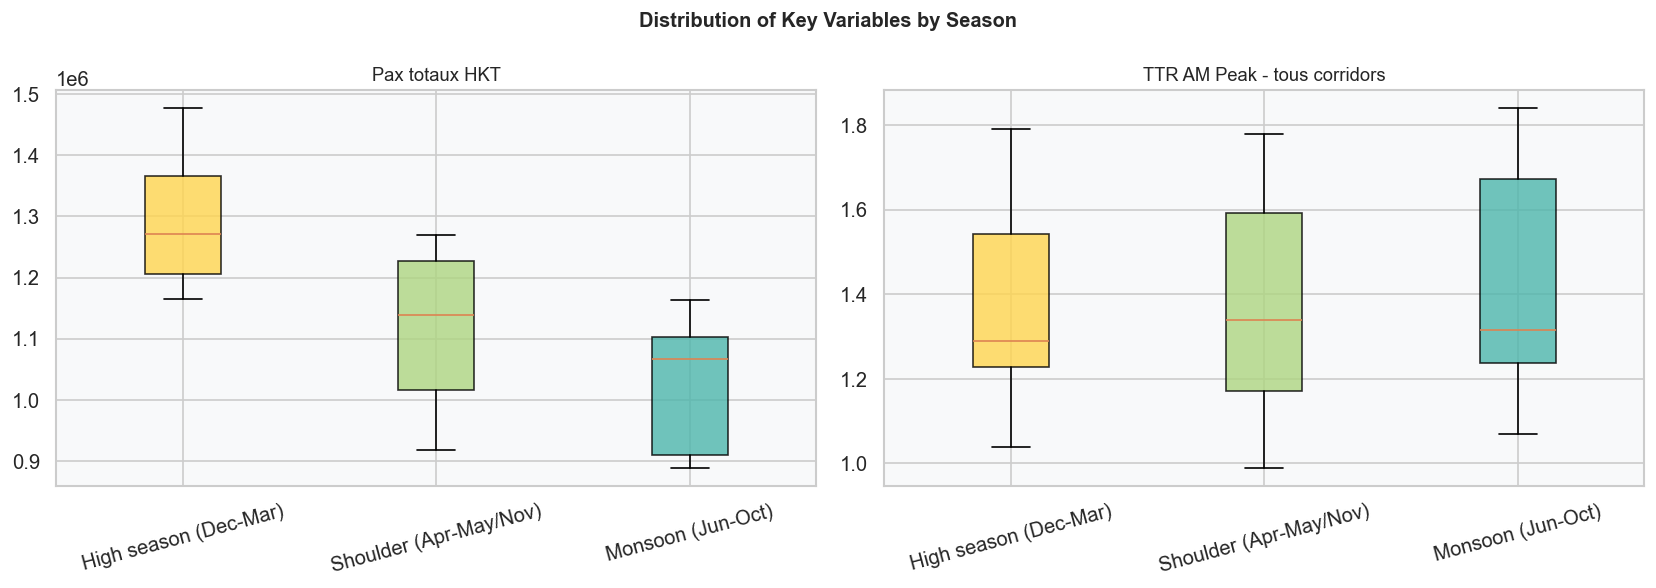

In [124]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Distribution of Key Variables by Season', fontsize=12, fontweight='bold')
season_colors = {'high_peak':'#FFD54F','shoulder':'#AED581','monsoon':'#4DB6AC'}

for ax, (col, src, label) in zip(axes, [
    ('flt_total_pax',       df_a, 'Pax totaux HKT'),
    ('tt_ratio_Weekday_AM1', df,  'TTR AM Peak - tous corridors'),
]):
    order_present = [s for s in SEASON_ORDER if s in src['season'].values]
    data_list = [src[src['season']==s][col].values for s in order_present]
    xlabels   = [SEASON_LABELS[s] for s in order_present]
    bp = ax.boxplot(data_list, labels=xlabels, patch_artist=True)
    for patch, s in zip(bp['boxes'], order_present):
        patch.set_facecolor(season_colors[s]); patch.set_alpha(0.8)
    ax.set_title(label, fontsize=11)
    ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('../final_data/figures/fig_season_distributions.png', bbox_inches='tight')
plt.show()


## 13. Synthèse & Points clés pour la thèse


In [125]:
print('=' * 70)
print('SYNTHÈSE EDA - POINTS CLÉS POUR LA THÈSE')
print('=' * 70)

print('\n📊 DATASET')
print(f'  {df.shape[0]} lignes × {df.shape[1]} colonnes')
print(f'  {df["corridor"].nunique()} corridors × 24 mois (Jan 2023 – Déc 2024)')
print(f'  {len(COL_GROUPS["Traffic_tt"])} colonnes tt_ratio (24 timesets granulaires)')
print(f'  0 valeurs manquantes')

print('\n🚗 CLASSEMENT DES CORRIDORS (TTR AM Peak — avg. 2023-2024)')
ranking = df.groupby('corridor')['tt_ratio_Weekday_AM1'].mean().sort_values(ascending=False)
for i, (corr, val) in enumerate(ranking.items(), 1):
    print(f'  {i}. {CORRIDOR_SHORT[corr]:12s} → TTR={val:.3f}')

print('\n📅 SAISONNALITÉ (TTR AM Peak moyen par saison)')
for season in SEASON_ORDER:
    if season not in df['season'].values: continue
    ttr = df[df['season']==season]['tt_ratio_Weekday_AM1'].mean()
    flt = df_a[df_a['season']==season]['flt_total_pax'].mean()/1000
    print(f'  {SEASON_LABELS[season]:42s} → TTR={ttr:.3f}, Pax={flt:.0f}k')

print('\n⏰ PICS DE CONGESTION PAR CORRIDOR (weekday)')
for corr in df['corridor'].unique():
    sub = df[df['corridor']==corr]
    worst_ts  = max(WEEKDAY_ORDER, key=lambda ts: sub[f'tt_ratio_{ts}'].mean())
    worst_val = sub[f'tt_ratio_{worst_ts}'].mean()
    night_val = sub['tt_ratio_Weekday_Night'].mean()
    print(f'  {CORRIDOR_SHORT[corr]:12s} → pic : {worst_ts} (TTR={worst_val:.3f}) | nuit : {night_val:.3f}')

print('\n🔗 TOP CORRÉLATIONS EXO → tt_ratio_Weekday_AM1 (tous corridors)')
top_corr = corr_full.loc[exo_cols, 'tt_ratio_Weekday_AM1'].abs().sort_values(ascending=False).head(5)
for feat, r in top_corr.items():
    print(f'  {feat:35s} |r|={r:.3f}')

print('\n✅ PROCHAINE ÉTAPE : scripts/prepare_dataset.py → features ML')


SYNTHÈSE EDA - POINTS CLÉS POUR LA THÈSE

📊 DATASET
  96 lignes × 103 colonnes
  4 corridors × 24 mois (Jan 2023 – Déc 2024)
  24 colonnes tt_ratio (24 timesets granulaires)
  0 valeurs manquantes

🚗 CLASSEMENT DES CORRIDORS (TTR AM Peak — avg. 2023-2024)
  1. Town→Rawai   → TTR=1.629
  2. Bypass       → TTR=1.517
  3. Airport      → TTR=1.267
  4. Patong       → TTR=1.188

📅 SAISONNALITÉ (TTR AM Peak moyen par saison)
  High season (Dec-Mar)                      → TTR=1.371, Pax=1297k
  Shoulder (Apr-May/Nov)                     → TTR=1.379, Pax=1116k
  Monsoon (Jun-Oct)                          → TTR=1.437, Pax=1029k

⏰ PICS DE CONGESTION PAR CORRIDOR (weekday)
  Airport      → pic : Weekday_PM1 (TTR=1.517) | nuit : 1.000
  Patong       → pic : Weekday_Evening (TTR=1.486) | nuit : 1.000
  Town→Rawai   → pic : Weekday_PM1 (TTR=1.872) | nuit : 1.000
  Bypass       → pic : Weekday_PM1 (TTR=1.543) | nuit : 1.000

🔗 TOP CORRÉLATIONS EXO → tt_ratio_Weekday_AM1 (tous corridors)
  cal_high_i